# Hand Gesture Recognition

In [ ]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy.fft import fft, fftfreq
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

from enum import IntEnum

from sklearn.preprocessing import RobustScaler

from pickle import dump

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import libemg

import gc

import sys
sys.path.append('../../uMyo_python_tools')

import importlib

import parameters
importlib.reload(parameters)

import preprocessing
importlib.reload(preprocessing)

In [ ]:
# global variables
TEST_SUBJECTS = ("gilbert", "nad", "gabriel", "rotraud")
DATA_DIR = "../../recordings/"
SENSOR_PLACEMENT = 0
GESTURES =  ("baseline", "fist", "peace", "up", "down", "lift")
# GESTURES =  ("fist", "index", "ok", "peace", "thumb", "open", "up", "down", "lift")
#GESTURES =  ("fist", "index", "middle", "ok", "peace", "thumb", "baseline")
DAYS = ("02_01_25", "27_12_24", "31_12_24")
NUM_CLASSES = len(GESTURES)
lf = parameters.LF
hf = parameters.HF
fs = parameters.FS
trim = parameters.TRIM
bandpass_order = parameters.BANDPASS_ORDER
outlier_rejection_stds = parameters.OUTLIER_REJECTION_STDS

PLOT_ALL_TIMELINE = True
NUM_SENSORS = parameters.NUM_SENSORS
NUM_READINGS = 8
RANDOM_STATE = 42
SUBSAMPLE_DATA = True
USE_FFT = parameters.USE_FFT
NUM_FFT_READINGS = parameters.NUM_FFT_READINGS

In [3]:
import re

def check_sensors_present(file, num_sensors=NUM_SENSORS):
    df = pd.read_csv(file)
    return len(df.columns) >= num_sensors * NUM_READINGS

# structure: recordings/date/data/*.csv
recordings = []
baseline_file = None

pattern = re.compile(rf"({'|'.join(TEST_SUBJECTS)})_({'|'.join(GESTURES)})\d*_{SENSOR_PLACEMENT}.csv")
# pattern = re.compile(rf"({'|'.join(TEST_SUBJECTS)})_({'|'.join(GESTURES)})1_{SENSOR_PLACEMENT}.csv")

for date_dir, _, filenames in os.walk(DATA_DIR):
    if date_dir.endswith('data') and any(day in date_dir for day in DAYS) and not 'static' in date_dir:
        for filename in filenames:
            if pattern.match(filename):
                gesture = next((gesture for gesture in GESTURES if gesture in filename), None)
                                
                emg_data_file = os.path.join(date_dir, filename)
                if check_sensors_present(emg_data_file):
                    recordings.append({
                        "gesture": gesture,
                        "raw_data_filepath": emg_data_file,
                        "imu_data_filepath": os.path.join(date_dir, f'imu_{filename}') if os.path.exists(os.path.join(date_dir, f'imu_{filename}')) else None,
                        'fft_data_filepath': os.path.join(date_dir, f'fft_{filename}') if os.path.exists(os.path.join(date_dir, f'fft_{filename}')) else None,
                    })
                else:
                    print(f"File {emg_data_file} has the wrong number of sensors. Should be {NUM_SENSORS}. Skipping.")

print(recordings)


[{'gesture': 'baseline', 'raw_data_filepath': '../../recordings/02_01_25\\data\\gilbert_baseline_0.csv', 'imu_data_filepath': '../../recordings/02_01_25\\data\\imu_gilbert_baseline_0.csv', 'fft_data_filepath': '../../recordings/02_01_25\\data\\fft_gilbert_baseline_0.csv'}, {'gesture': 'down', 'raw_data_filepath': '../../recordings/02_01_25\\data\\gilbert_down_0.csv', 'imu_data_filepath': '../../recordings/02_01_25\\data\\imu_gilbert_down_0.csv', 'fft_data_filepath': '../../recordings/02_01_25\\data\\fft_gilbert_down_0.csv'}, {'gesture': 'fist', 'raw_data_filepath': '../../recordings/02_01_25\\data\\gilbert_fist_0.csv', 'imu_data_filepath': '../../recordings/02_01_25\\data\\imu_gilbert_fist_0.csv', 'fft_data_filepath': '../../recordings/02_01_25\\data\\fft_gilbert_fist_0.csv'}, {'gesture': 'peace', 'raw_data_filepath': '../../recordings/02_01_25\\data\\gilbert_peace_0.csv', 'imu_data_filepath': '../../recordings/02_01_25\\data\\imu_gilbert_peace_0.csv', 'fft_data_filepath': '../../recor

In [4]:
if USE_FFT:
    for recording in recordings:
        if not recording["fft_data_filepath"]:
            print(f'Recording without fft_file detected. {recording["raw_data_filepath"]}')
            recordings.remove(recording)

In [5]:
dfs = [[] for _ in range(NUM_CLASSES)]
fft_dfs = [[] for _ in range(NUM_CLASSES)]

for recording in recordings:
    dfs[GESTURES.index(recording["gesture"])].append(pd.read_csv(recording["raw_data_filepath"], header=None))
    if USE_FFT:
        fft_dfs[GESTURES.index(recording["gesture"])].append(pd.read_csv(recording["fft_data_filepath"], header=None))

In [6]:
def get_min_df_array_len(dfs):
    min_len = min([len(df_) for df in dfs for df_ in df])
    return min_len

def get_min_df_len(dfs):
    min_len = min([len(df) for df in dfs])
    return min_len

def get_random_chunk_starts(dfs, chunk_len):
    starts = []
    for df in dfs:
        if len(df) == chunk_len:
            starts.append(0)
        else:
            starts.append(np.random.randint(0, len(df) - chunk_len))
    return starts

def get_random_df_chunk(df, start, chunk_len, num_readings=NUM_READINGS):
    if start == 0:
        return df.iloc[:, 0:(NUM_SENSORS*num_readings)]
    return df.iloc[start:start+chunk_len, 0:(NUM_SENSORS*num_readings)]

# def get_random_df_chunk(df, chunk_len):
#     if len(df) == chunk_len:
#         return df.iloc[:, 0:(NUM_SENSORS*NUM_READINGS)]
#     start = np.random.randint(0, len(df) - chunk_len)
#     return df.iloc[start:start+chunk_len, 0:(NUM_SENSORS*NUM_READINGS)]

In [7]:
concat_dfs = []
concat_fft_dfs = []

for i in range(NUM_CLASSES):
    concat_dfs.append(pd.concat(dfs[i], ignore_index=True).iloc[:, 0:(NUM_SENSORS*NUM_READINGS)])
    if USE_FFT:
        concat_fft_dfs.append(pd.concat(fft_dfs[i], ignore_index=True).iloc[:, 0:(NUM_SENSORS*NUM_FFT_READINGS)])

In [8]:
print([len(df) for df in concat_dfs])
if USE_FFT:
    print([len(df) for df in concat_fft_dfs])

[80390, 81686, 76863, 84742, 83331, 54593]
[80390, 81685, 76863, 84742, 83331, 54592]


Subsample if desired:

In [9]:
if SUBSAMPLE_DATA:
    min_len = get_min_df_len(concat_dfs)
    starts = get_random_chunk_starts(concat_dfs, min_len)
    concat_dfs = [get_random_df_chunk(df, start, min_len) for (df, start) in zip(concat_dfs, starts)]
    if USE_FFT:
        concat_fft_dfs = [get_random_df_chunk(df, start, min_len, NUM_FFT_READINGS) for (df, start) in zip(concat_fft_dfs, starts)]

In [10]:
print([len(df) for df in concat_dfs])
if USE_FFT:
    print([len(df) for df in concat_fft_dfs])

[54593, 54593, 54593, 54593, 54593, 54593]
[54593, 54593, 54593, 54593, 54593, 54592]


In [11]:
if USE_FFT:
    for i in range(len(concat_fft_dfs)):
        concat_fft_dfs[i] = concat_fft_dfs[i].iloc[:, [i*NUM_FFT_READINGS+j+1 for i in range(0, NUM_SENSORS) for j in range(NUM_FFT_READINGS-1)]]
        concat_fft_dfs[i].columns = range(concat_fft_dfs[i].columns.size)

Combine dataframes

In [12]:
sensor_data = pd.concat(concat_dfs, ignore_index=True, axis=0)
labels = sum([[i] * len(concat_dfs[i]) for i in range(NUM_CLASSES)], [])
print(sensor_data.head())

if USE_FFT:
    fft_data = pd.concat(concat_fft_dfs, ignore_index=True)
    print(fft_data.head())

      0      1      2      3      4      5      6      7      8      9   ...  \
0  18919  18923  18947  18912  18950  18942  18984  18975  17523  17519  ...   
1  18919  18923  18947  18912  18950  18942  18984  18975  17523  17519  ...   
2  18919  18923  18947  18912  18950  18942  18984  18975  17523  17519  ...   
3  18919  18923  18947  18912  18950  18942  18984  18975  17523  17519  ...   
4  18919  18923  18947  18912  18950  18942  18984  18975  17632  17643  ...   

      30     31     32     33     34     35     36     37     38     39  
0  17523  17484  18578  18601  18614  18607  18614  18614  18625  18631  
1  17594  17620  18578  18601  18614  18607  18614  18614  18625  18631  
2  17594  17620  18578  18601  18614  18607  18614  18614  18625  18631  
3  17594  17620  18593  18612  18629  18625  18622  18627  18632  18649  
4  17594  17620  18593  18612  18629  18625  18622  18627  18632  18649  

[5 rows x 40 columns]
   0   1   2   3   4   5    6   7   8    9   10  11 

# Data visualization

## Sensor signals

In [14]:
def plot_time_signals(dataframe, row_index, title):
    row_data = dataframe.iloc[row_index, :]

    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(row_data.values, NUM_SENSORS, axis=0)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_time_signals(dataframe, title, preprocessor=None, filter=False):    
    # Plot each sensor's signal
    signals = np.array_split(dataframe.values, NUM_SENSORS, axis=1)
    fig, axs = plt.subplots(NUM_SENSORS // 2 + NUM_SENSORS % 2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, NUM_SENSORS):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        if filter:
            print('Raw SNR: ', preprocessor.signaltonoise(sigs, sensor))
            sigs = preprocessor.preprocess(sigs, sensor)
            print('Processed SNR: ', preprocessor.signaltonoise(sigs, sensor))
        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()

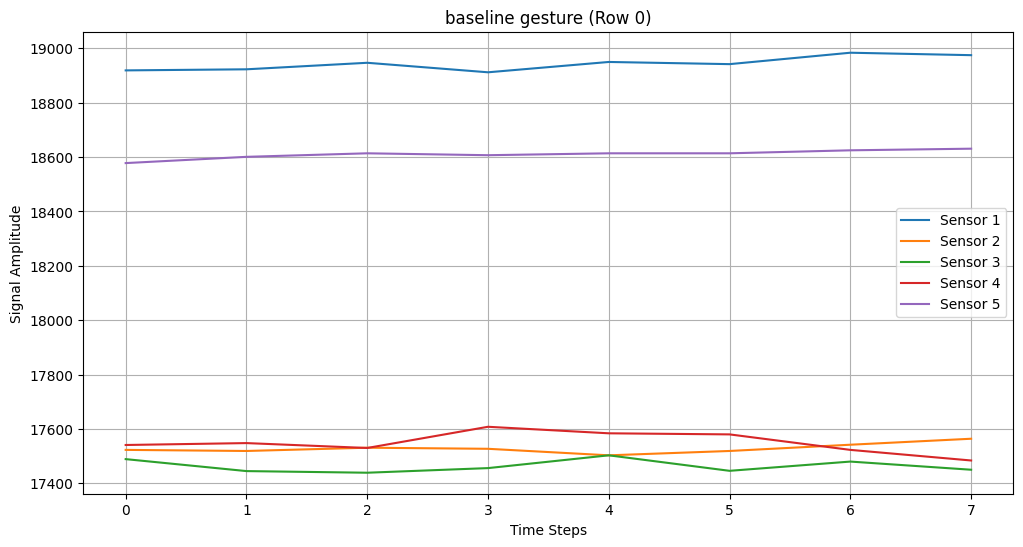

In [15]:
plot_time_signals(concat_dfs[0], row_index=0, title=f'{GESTURES[0]} gesture')

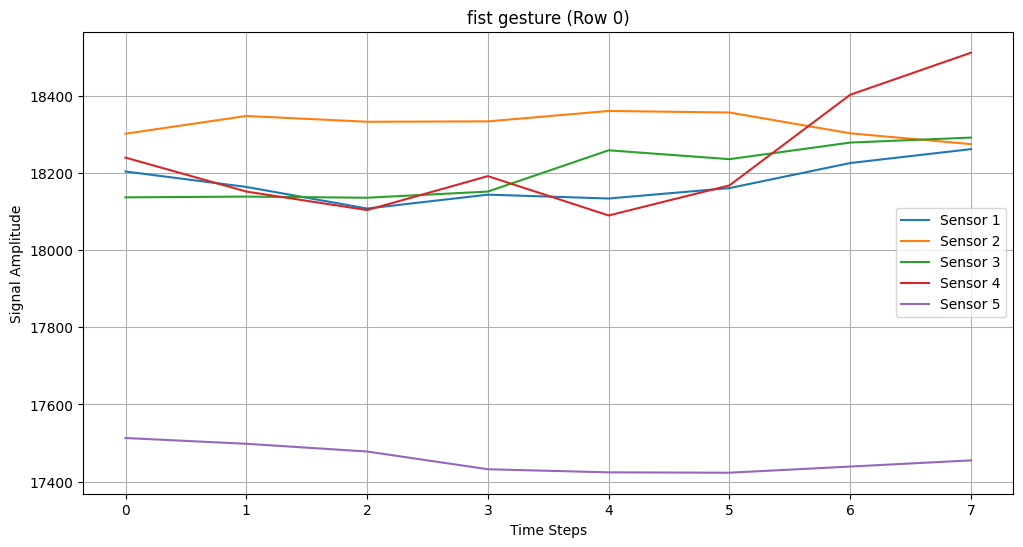

In [16]:
plot_time_signals(concat_dfs[1], row_index=0, title=f'{GESTURES[1]} gesture')

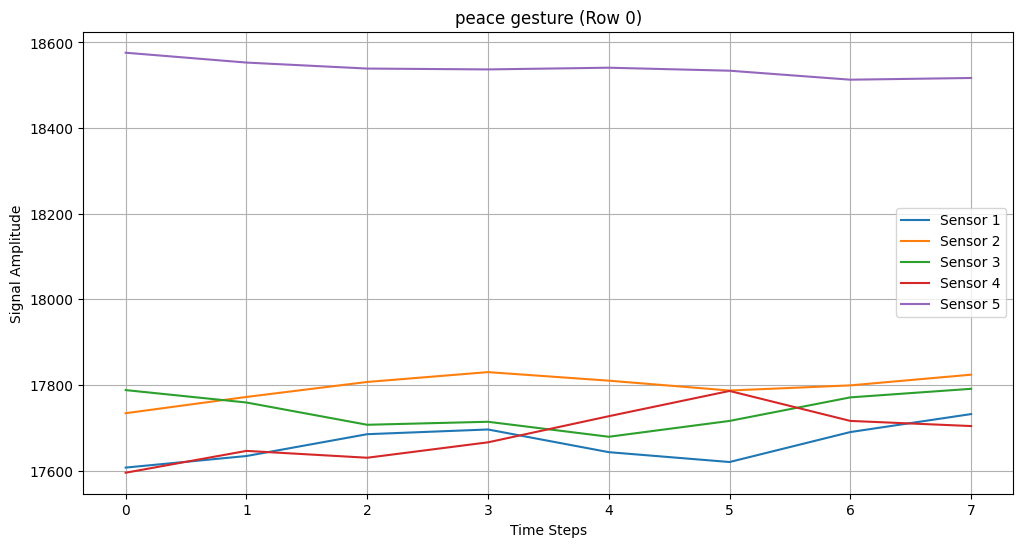

In [17]:
plot_time_signals(concat_dfs[2], row_index=0, title=f'{GESTURES[2]} gesture')

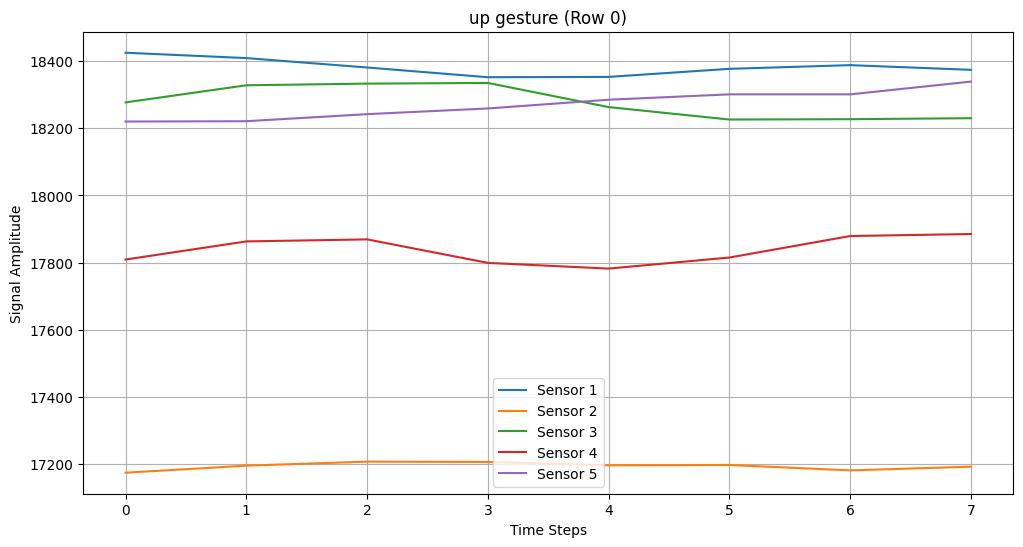

In [18]:
plot_time_signals(concat_dfs[3], row_index=0, title=f'{GESTURES[3]} gesture')

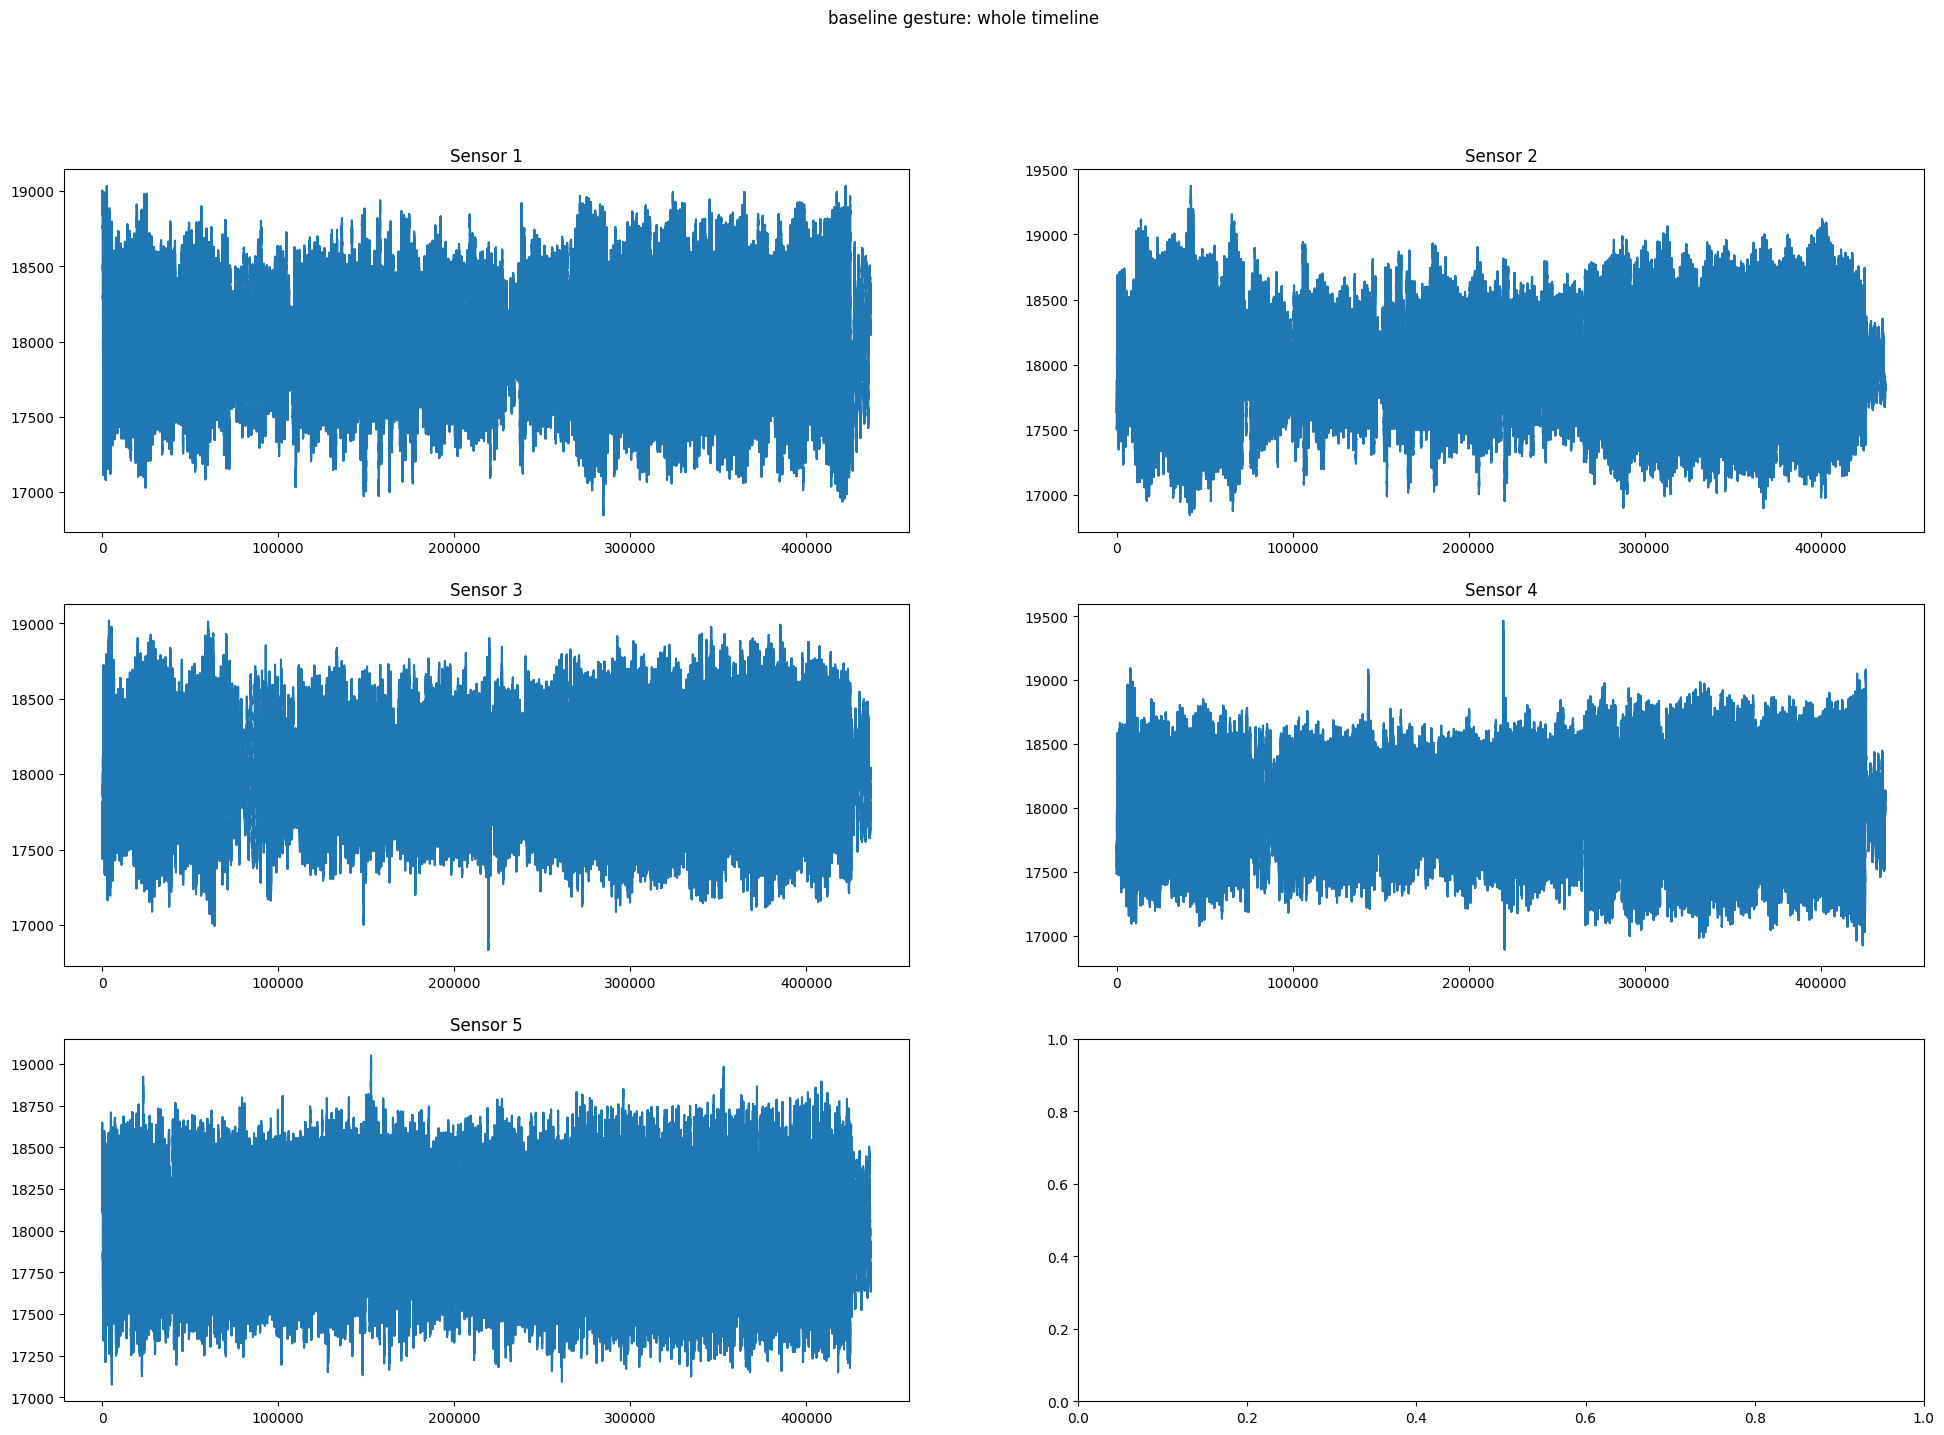

C:\Users\Gilbert\AppData\Local\Temp\ipykernel_2144\3058859634.py:126: RuntimeWarning: divide by zero encountered in divide
  snr = 10 * np.log10(power_signal / self.baseline_noise[sensor_num])


Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


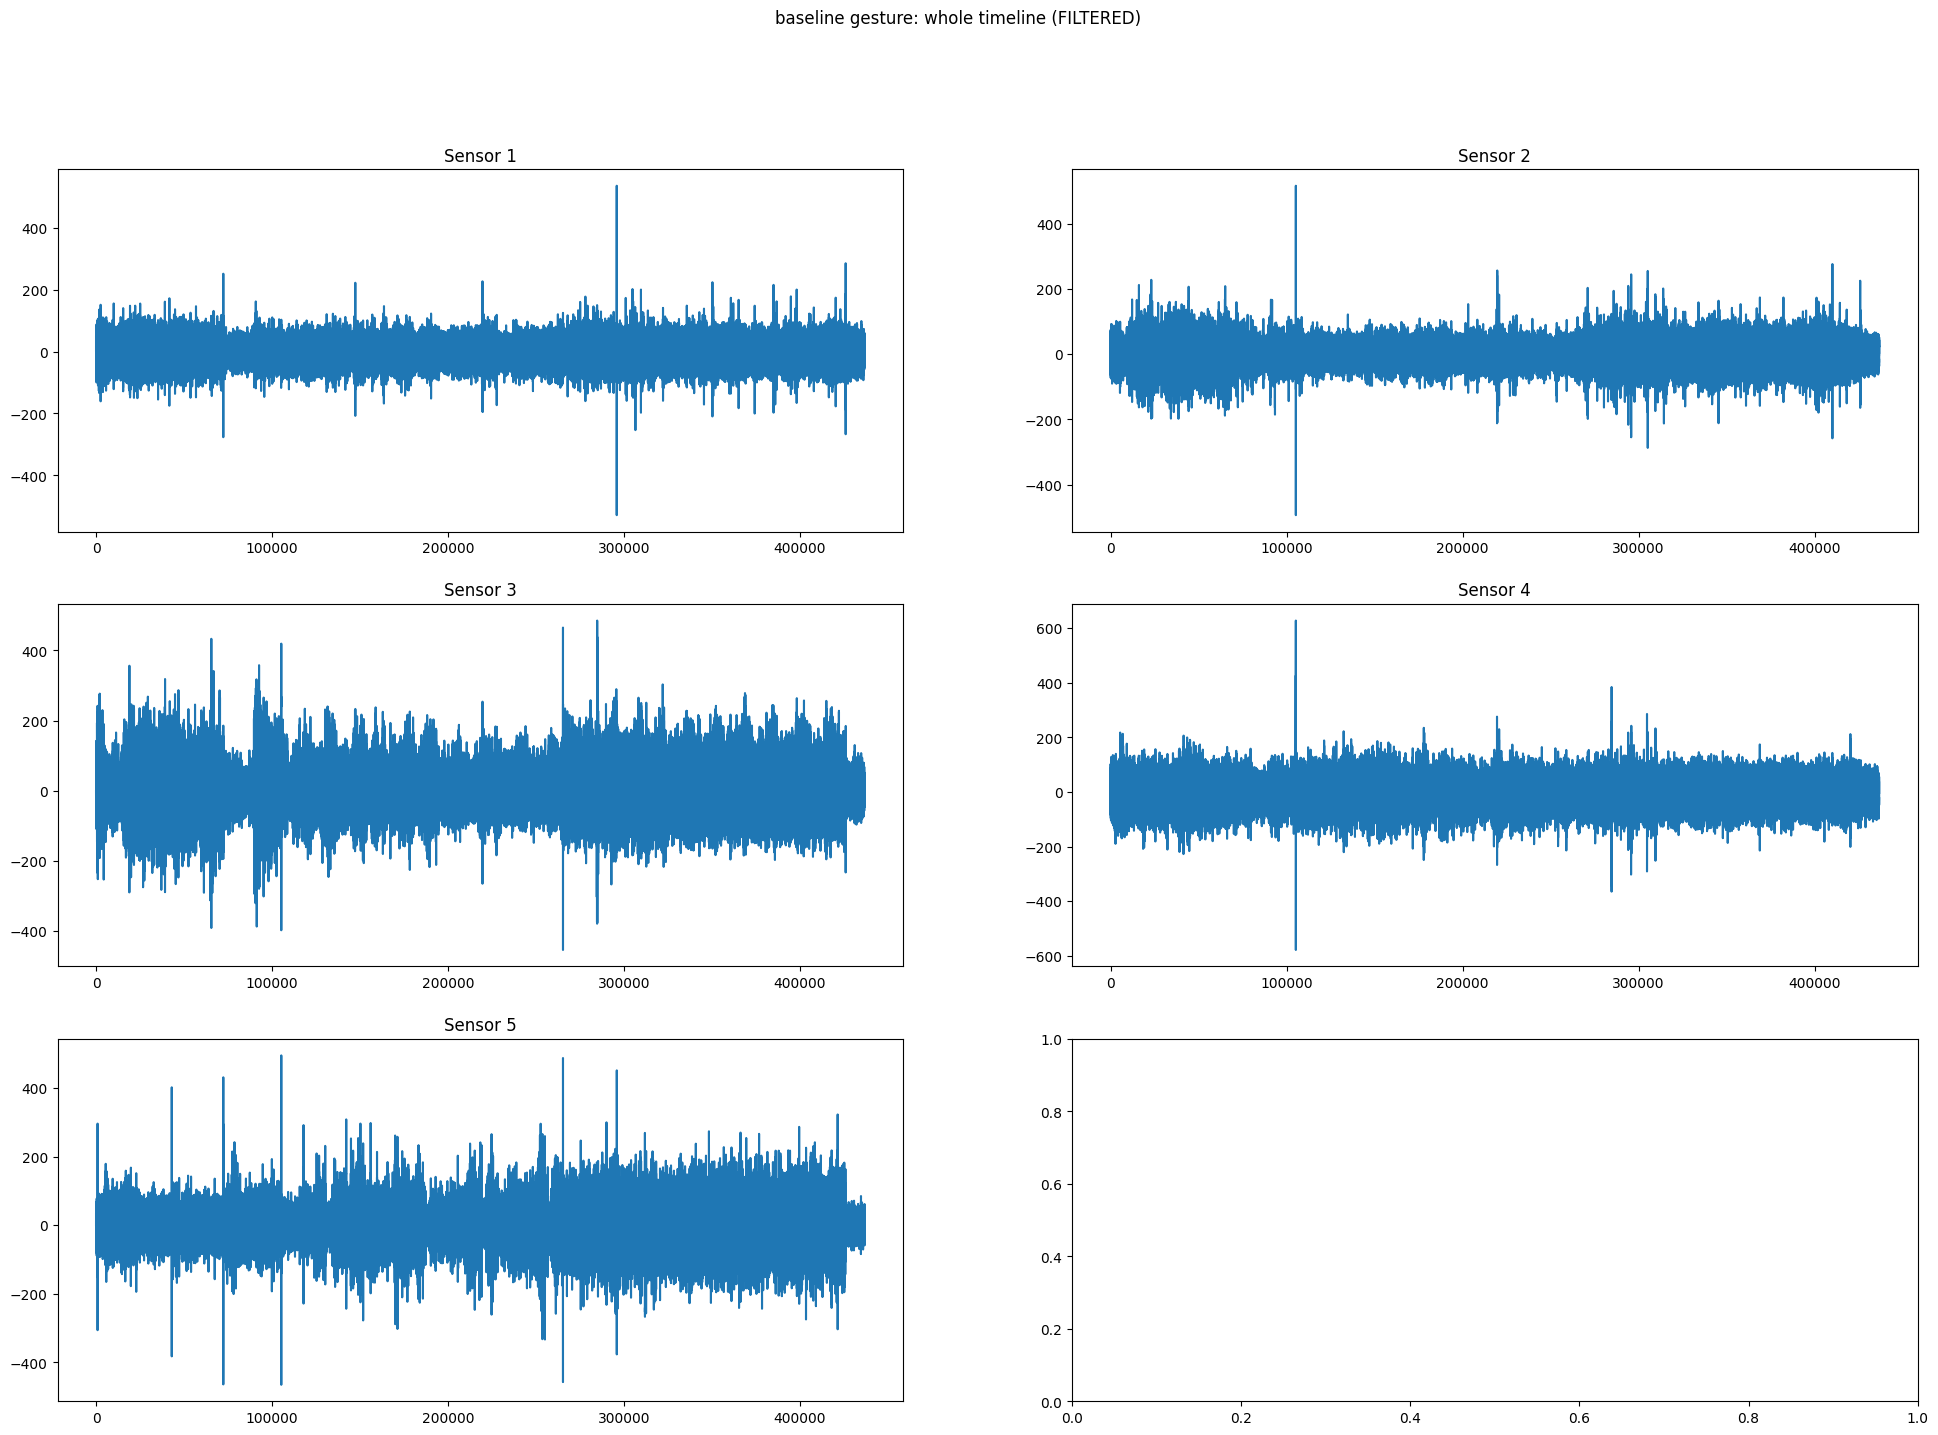

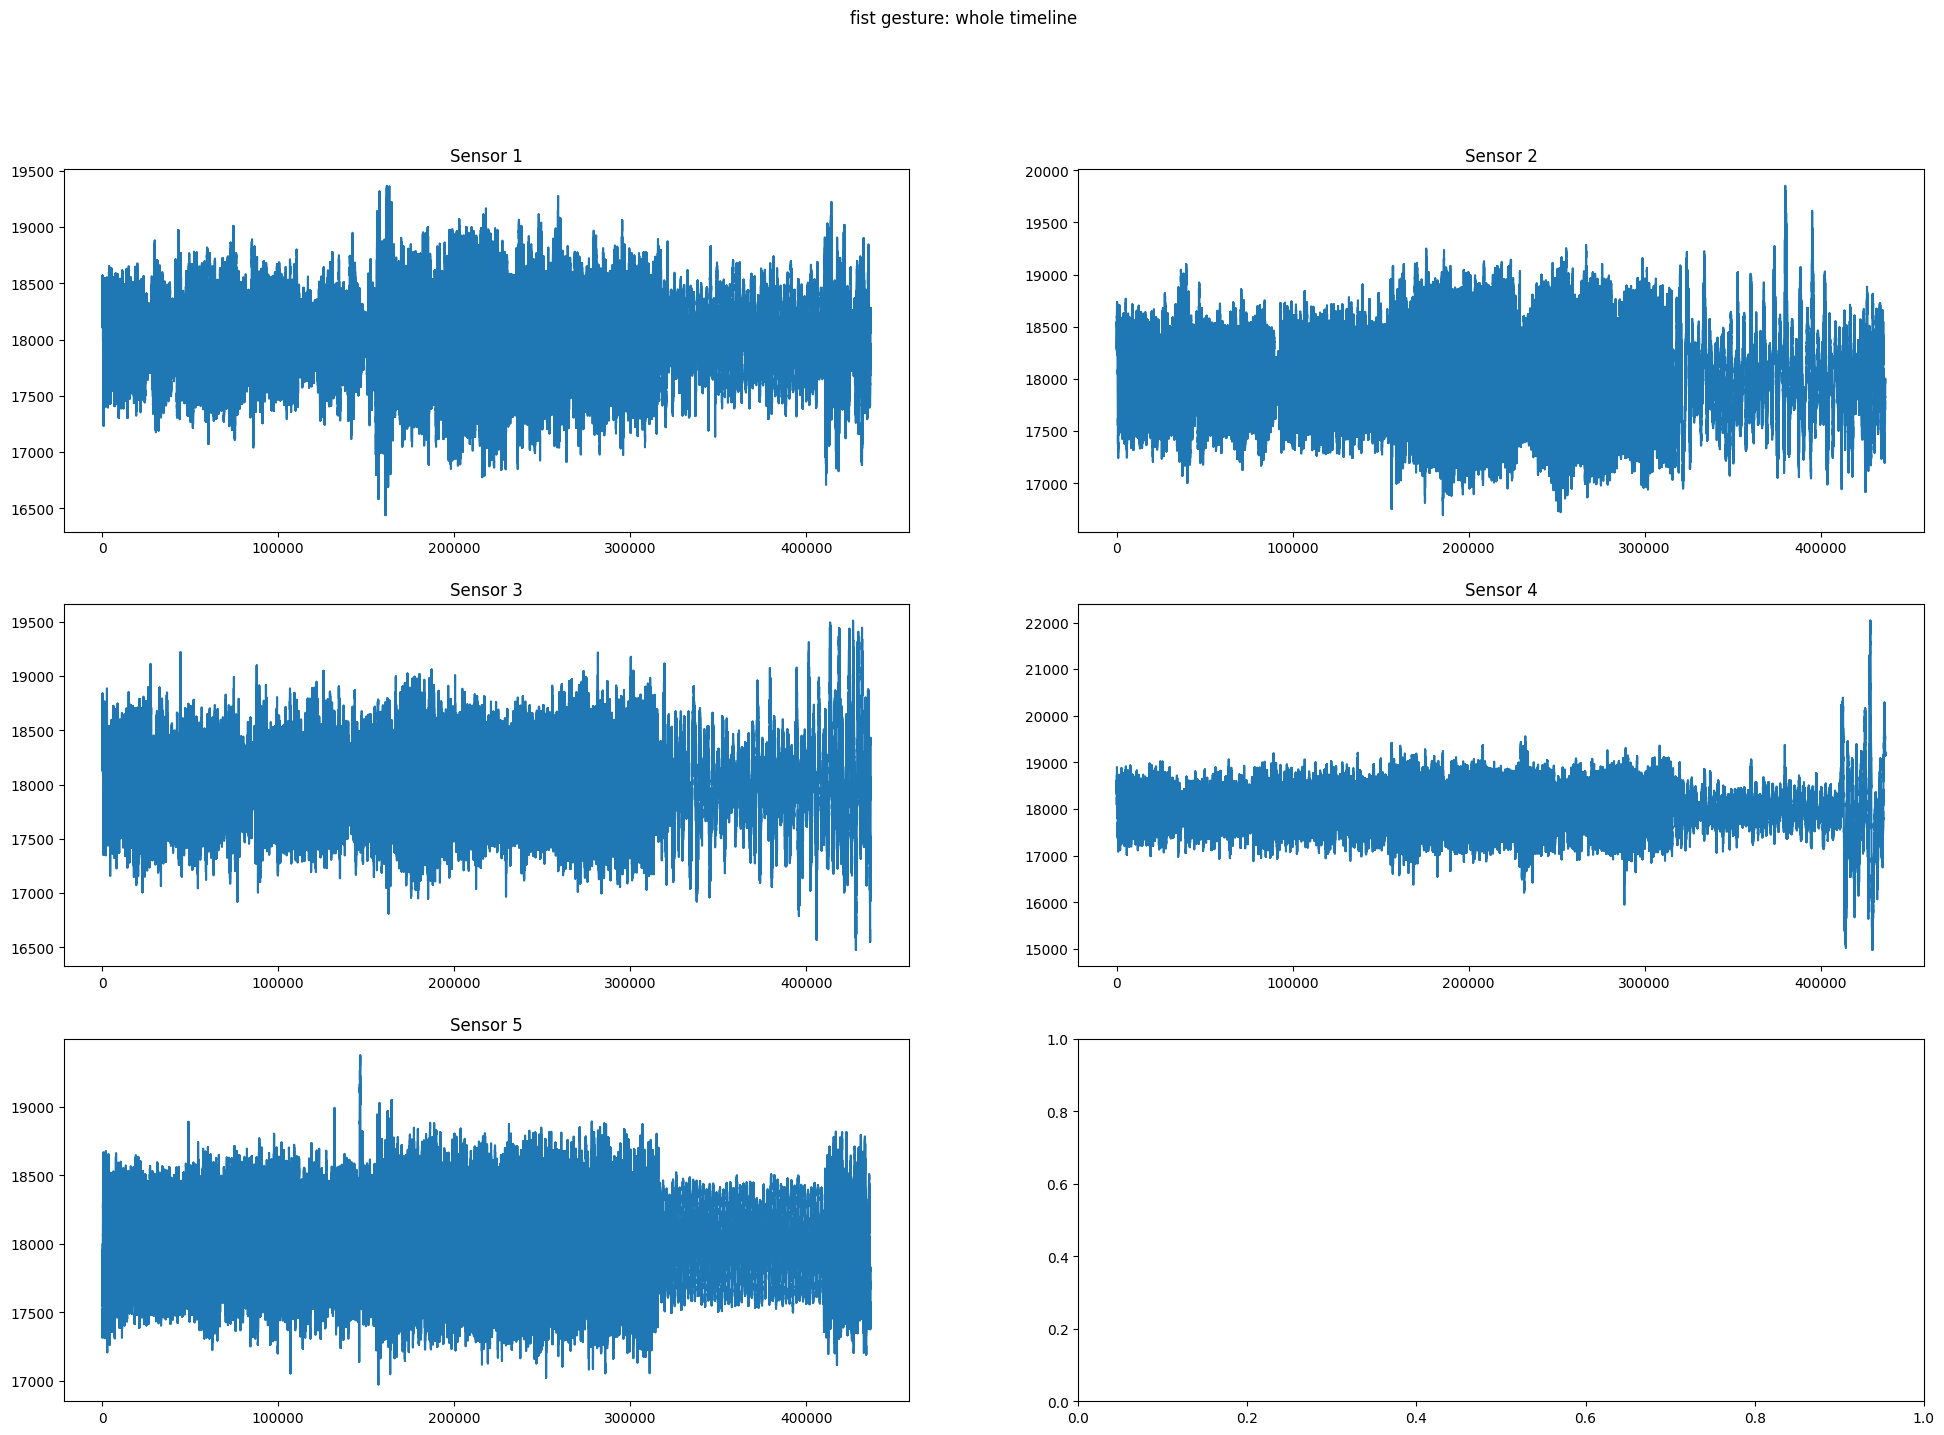

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


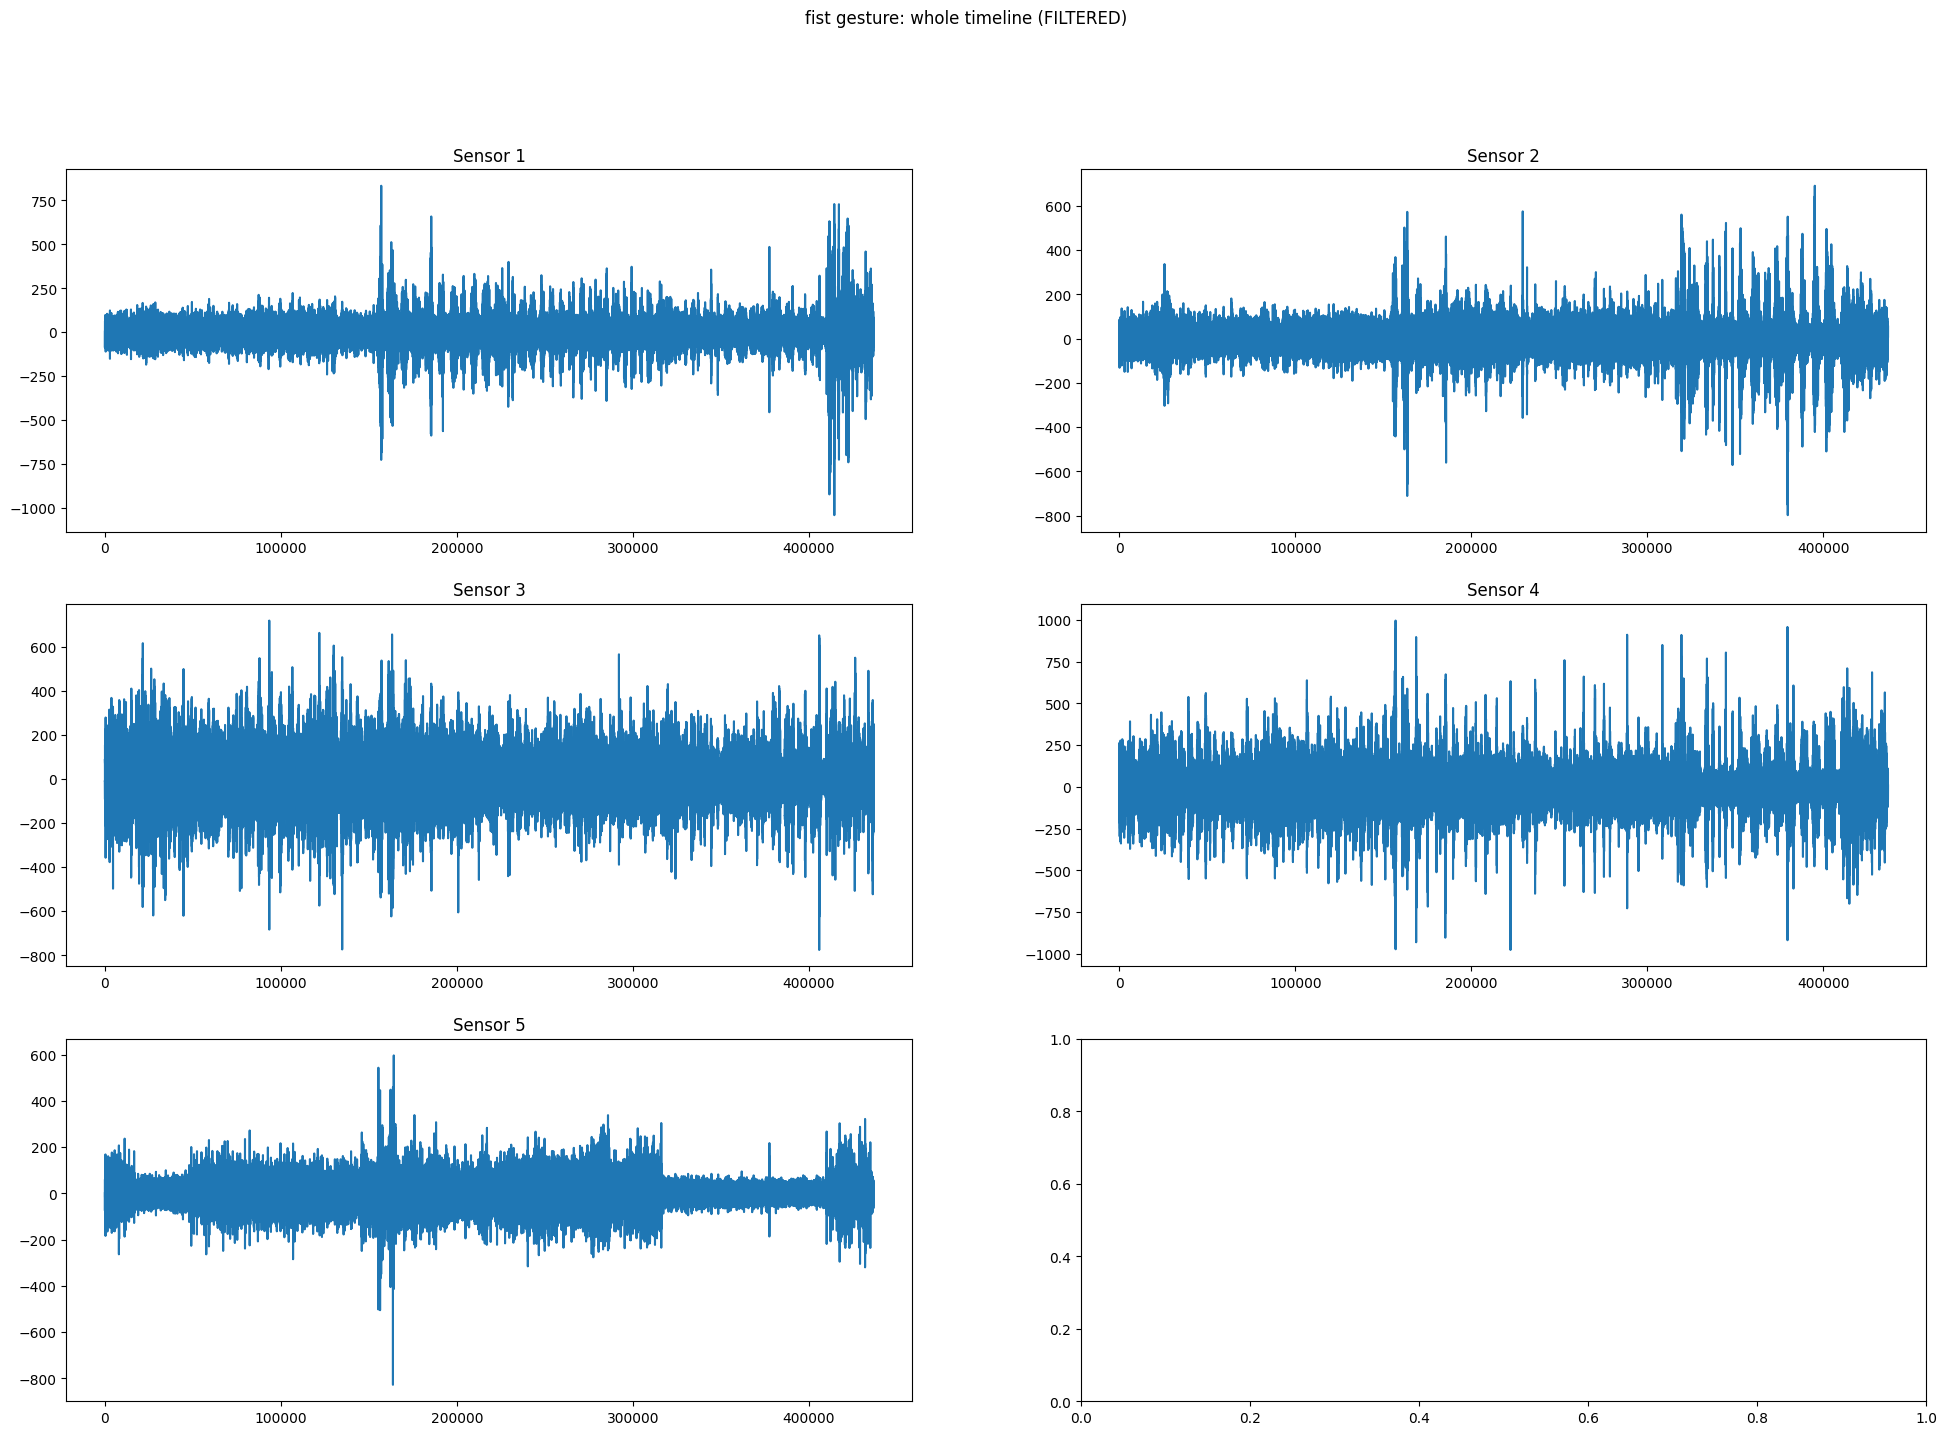

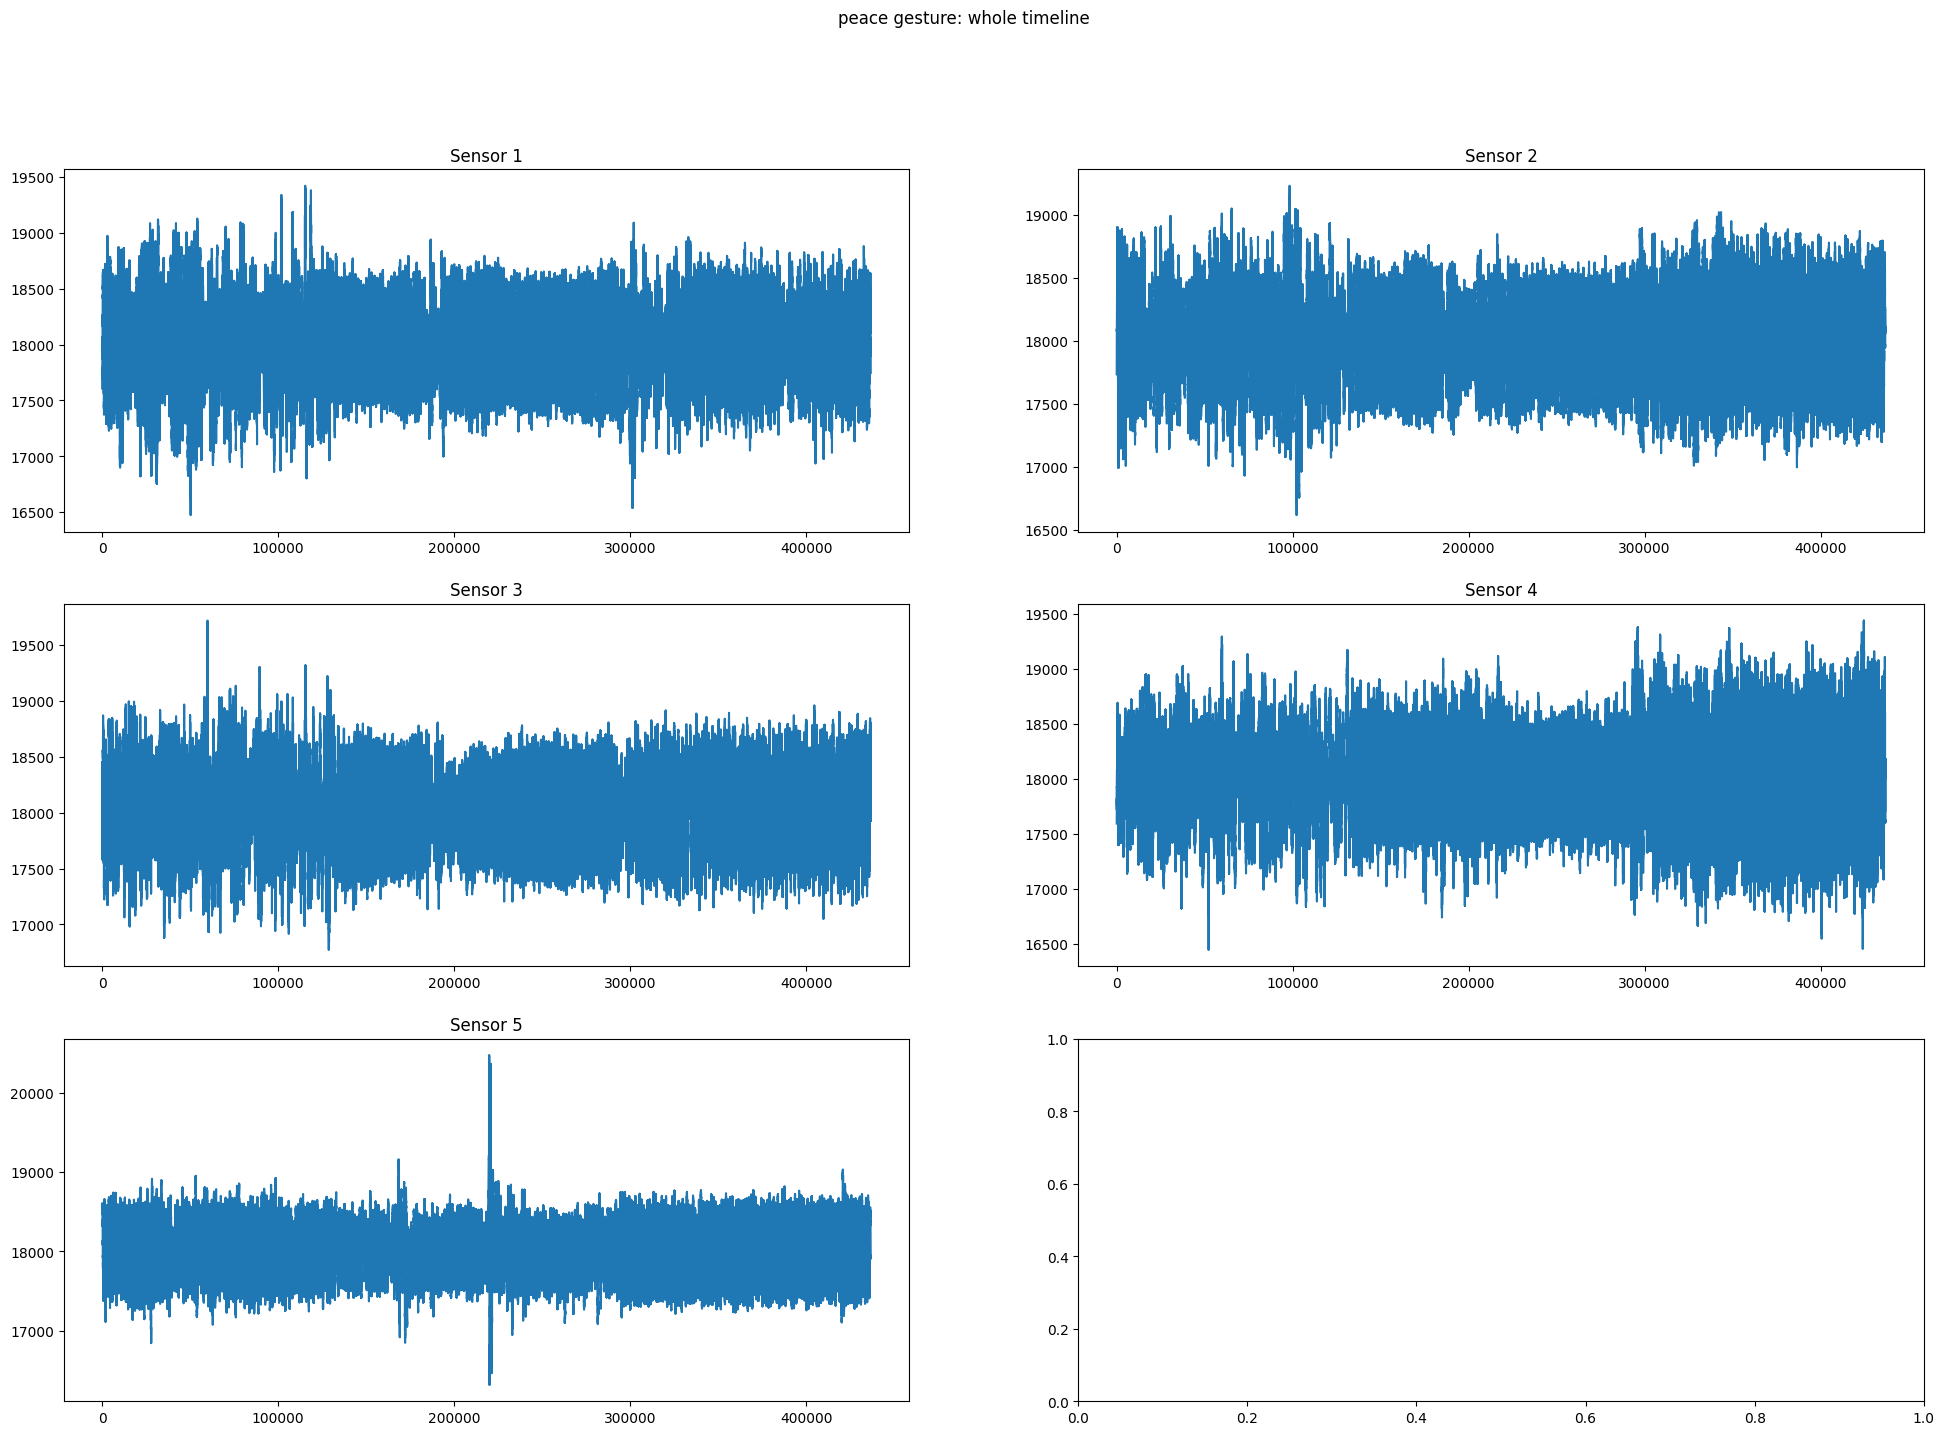

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


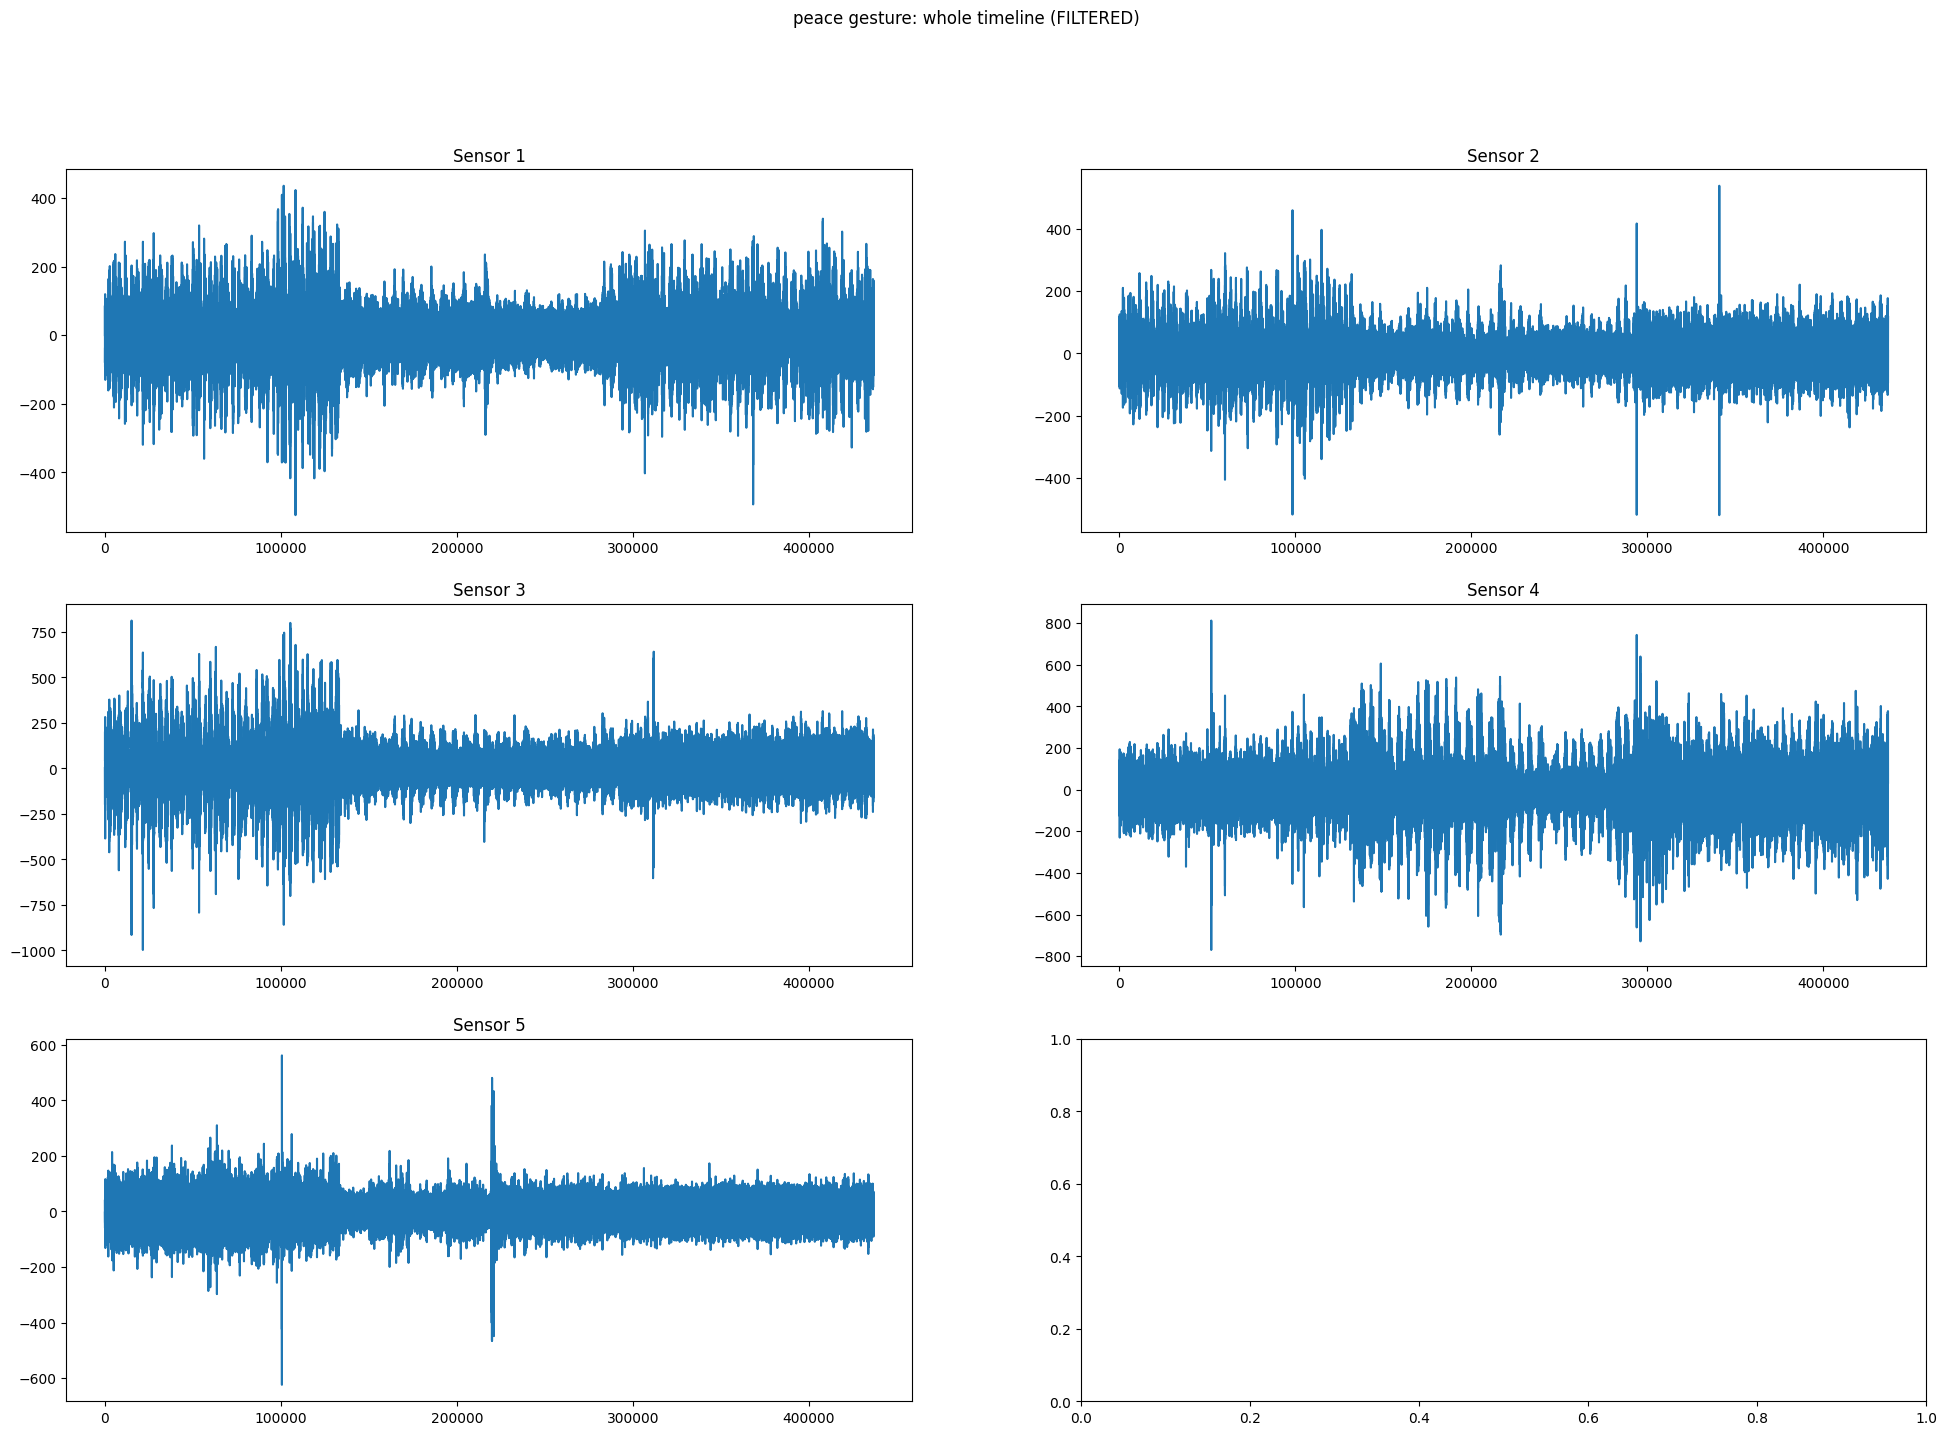

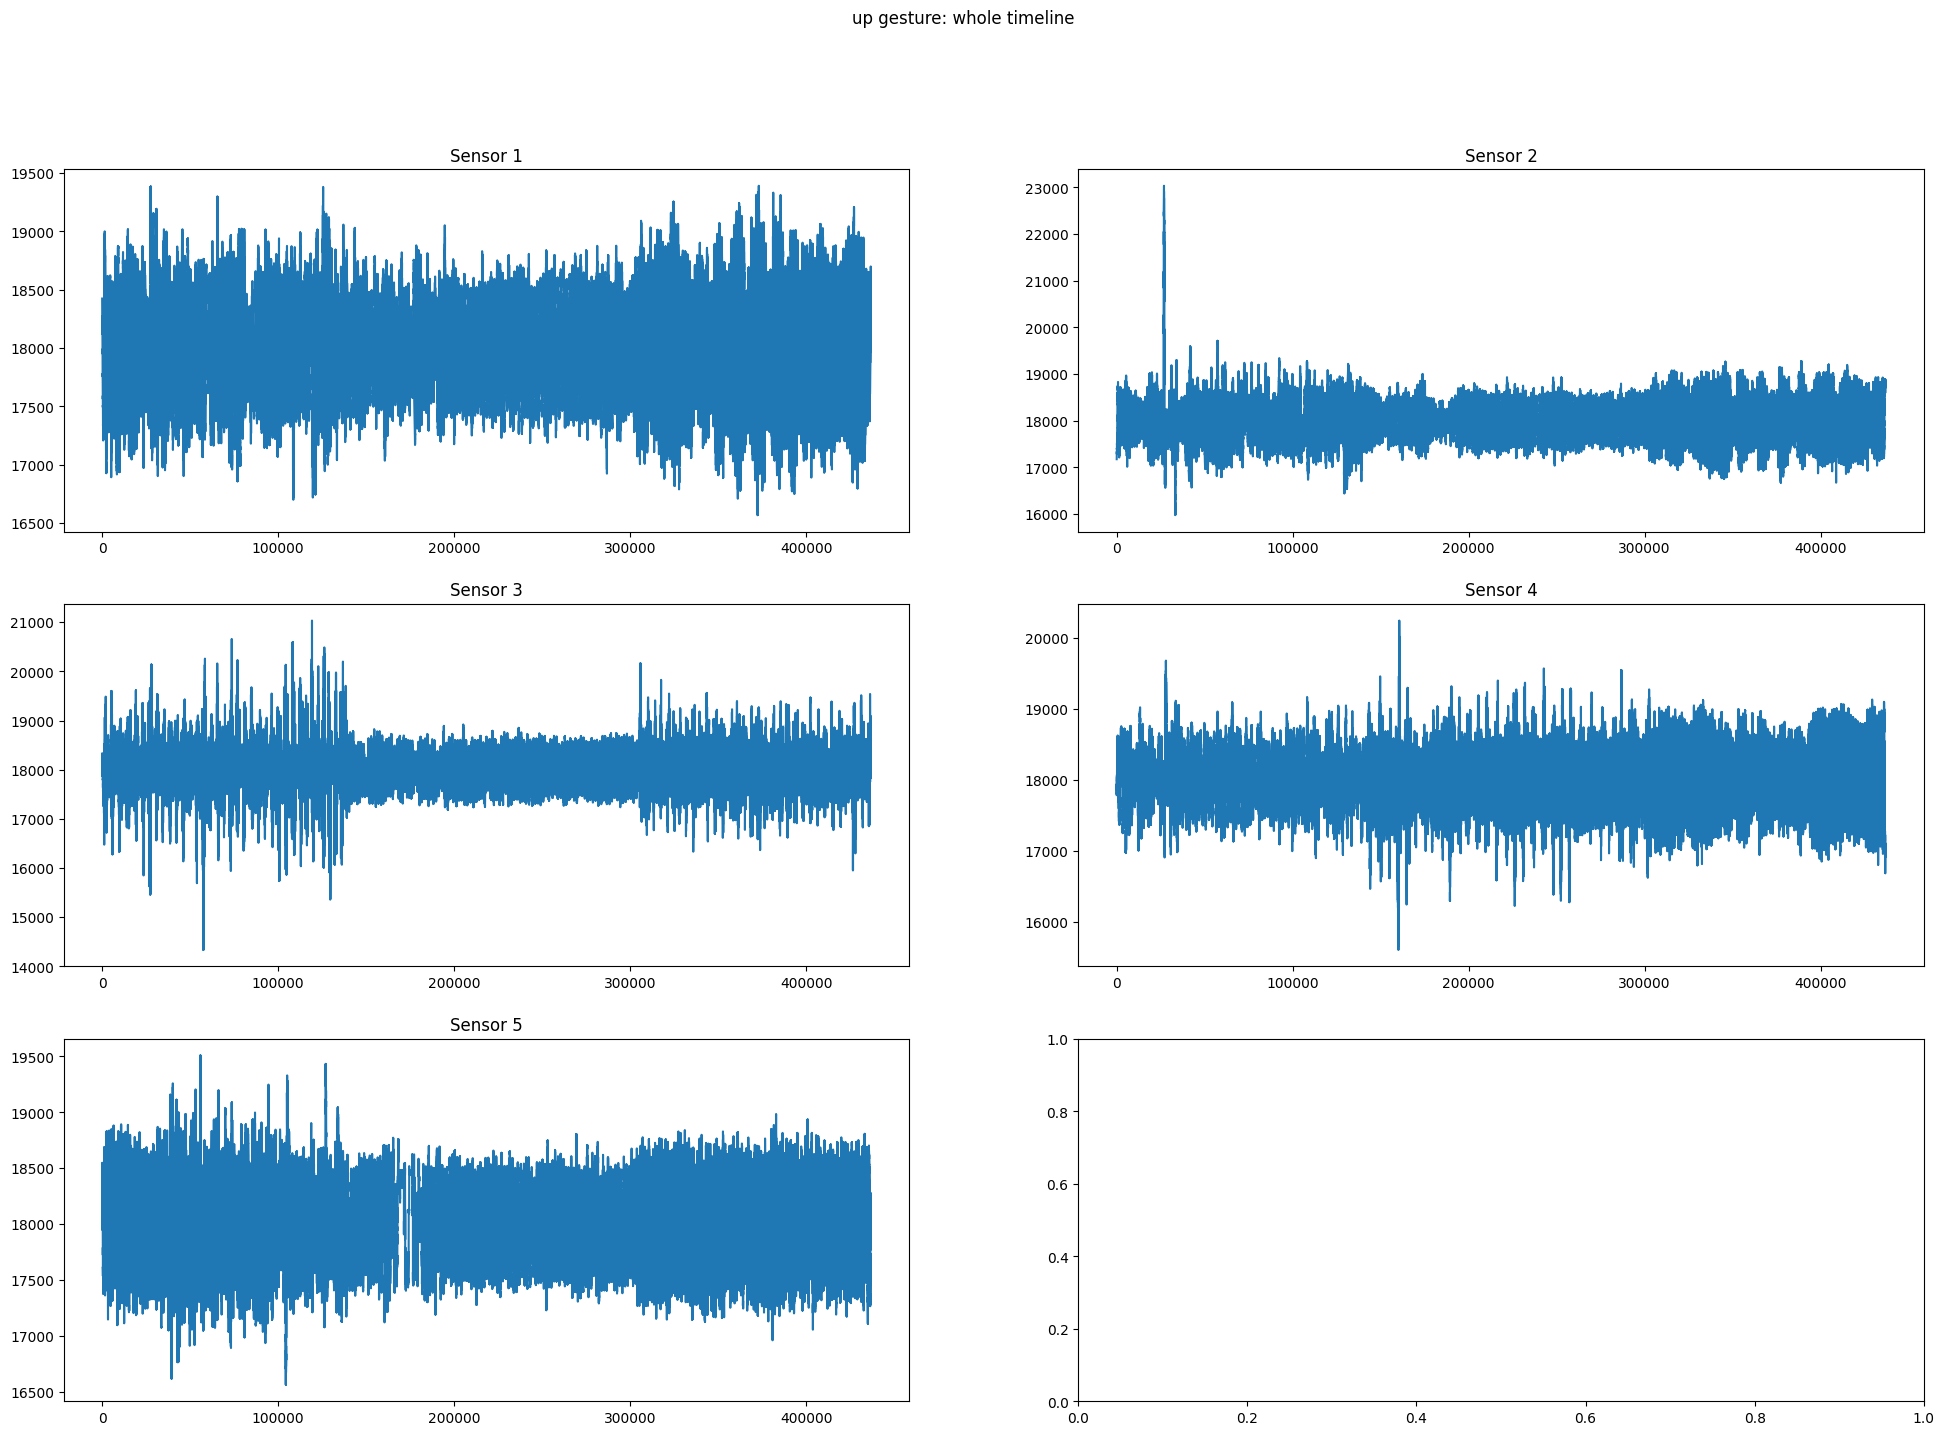

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


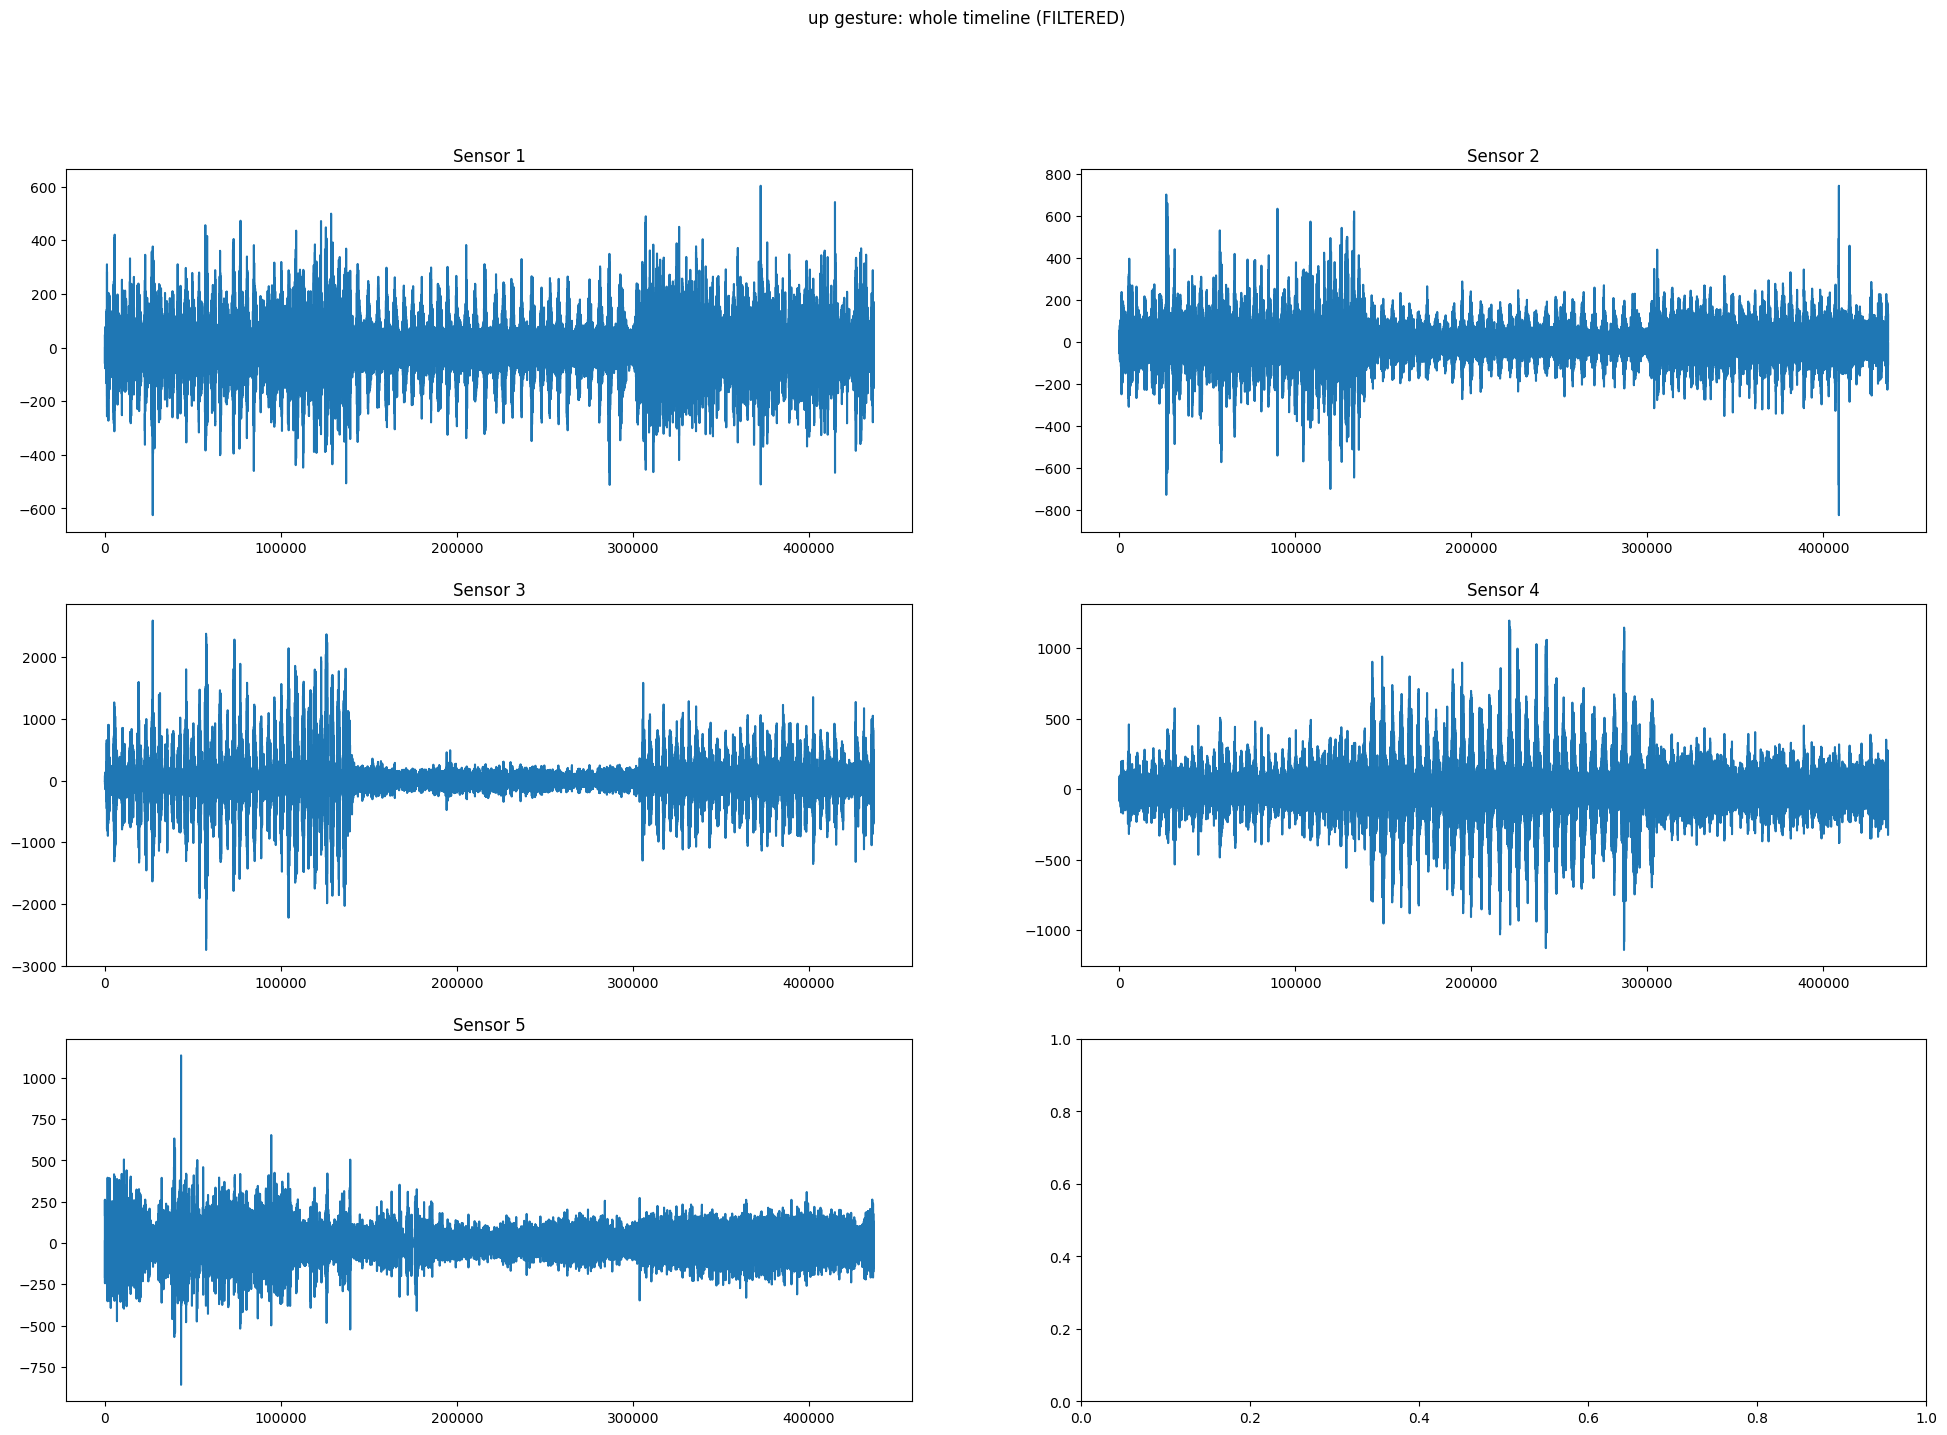

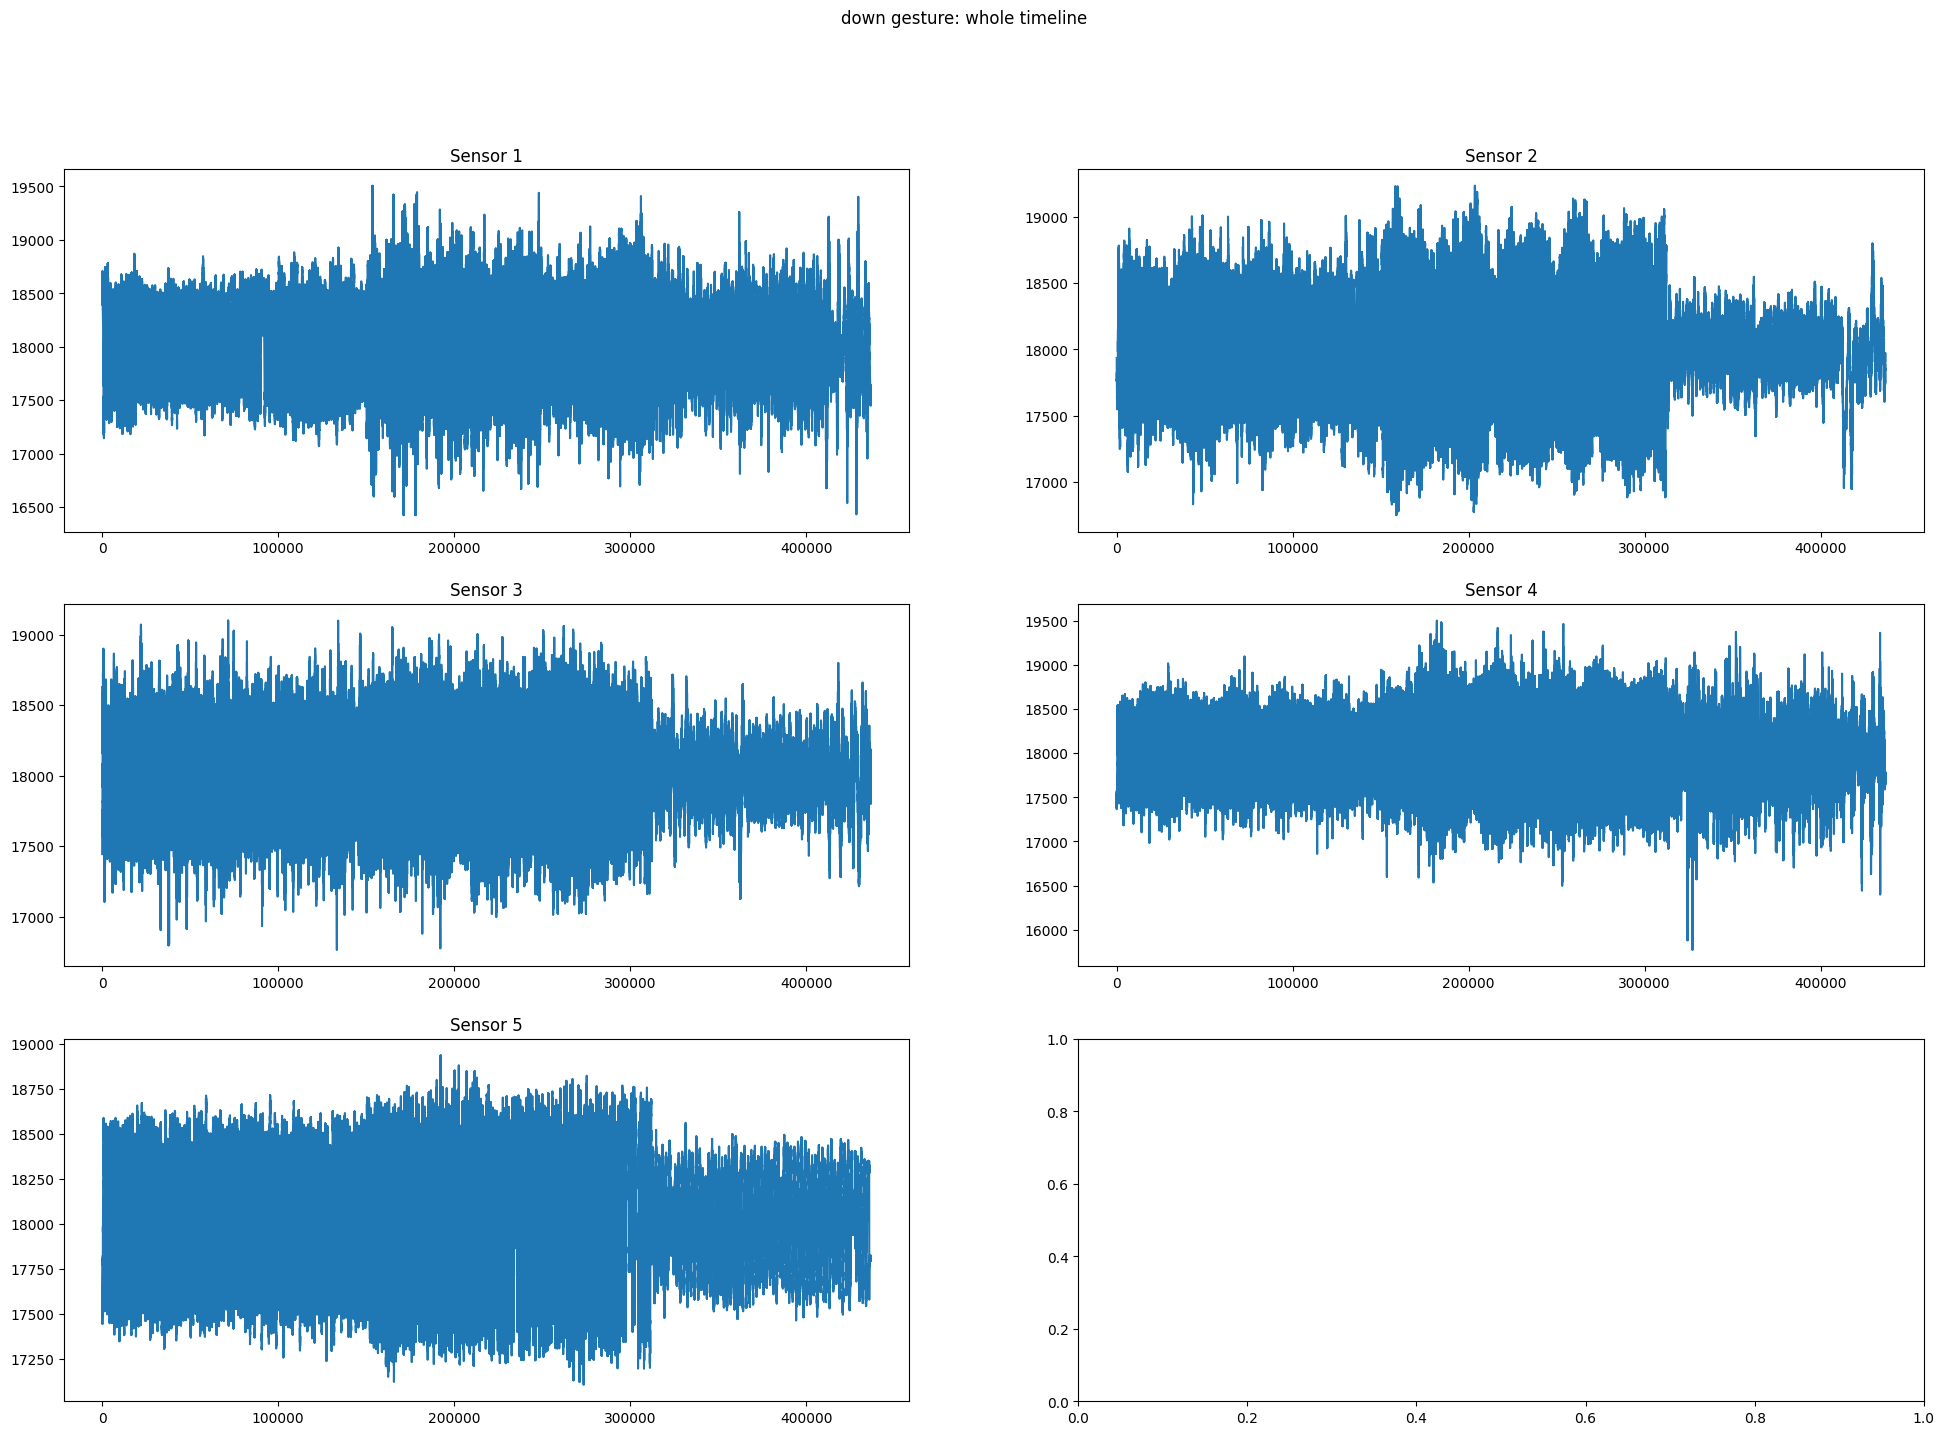

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


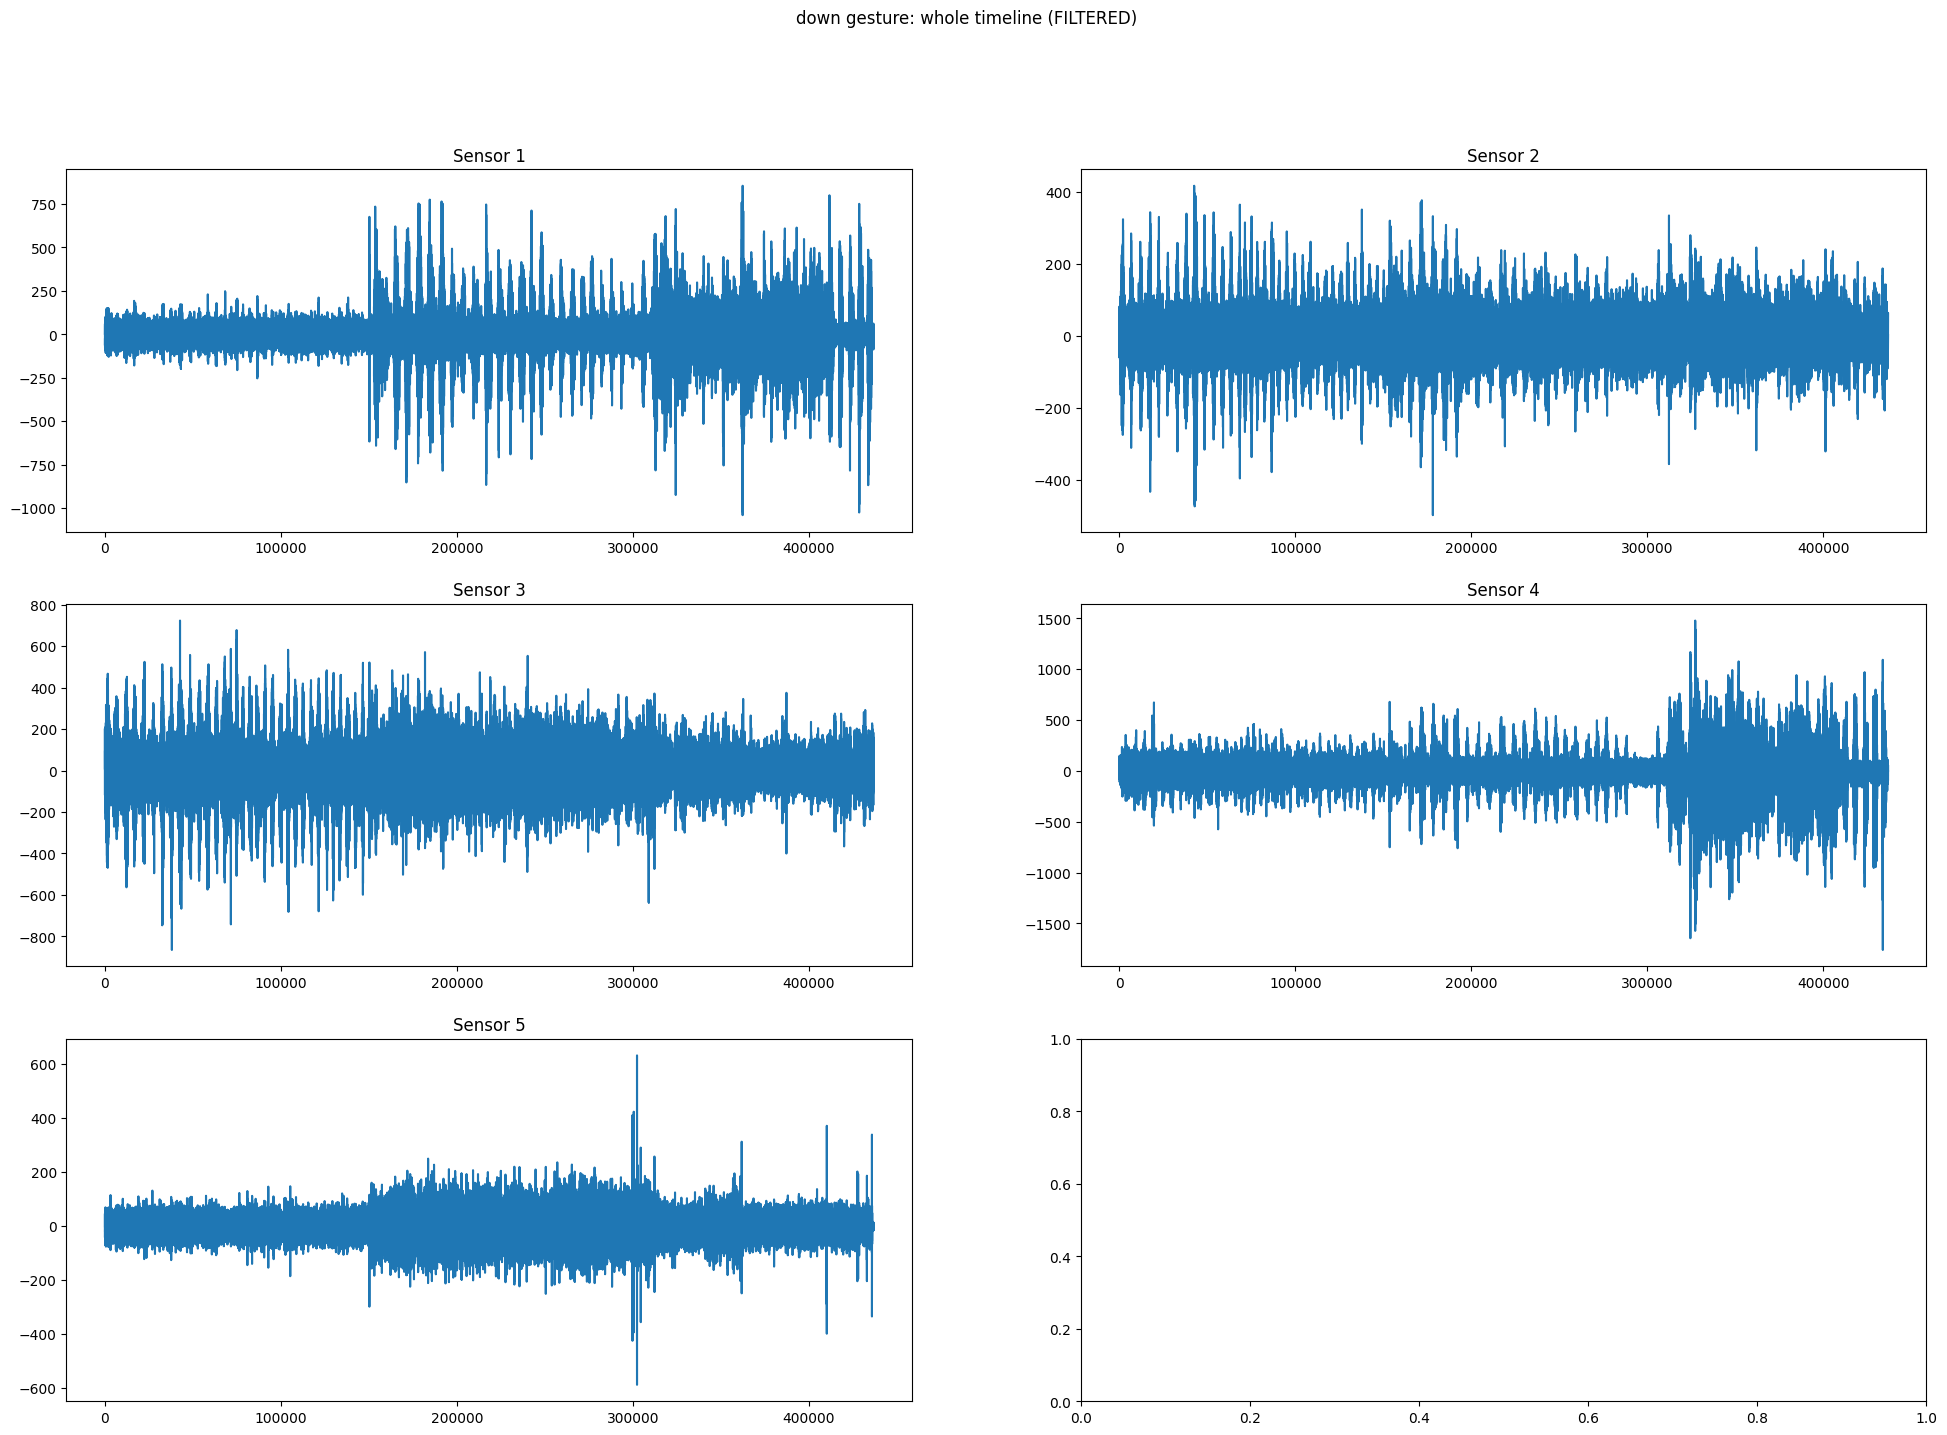

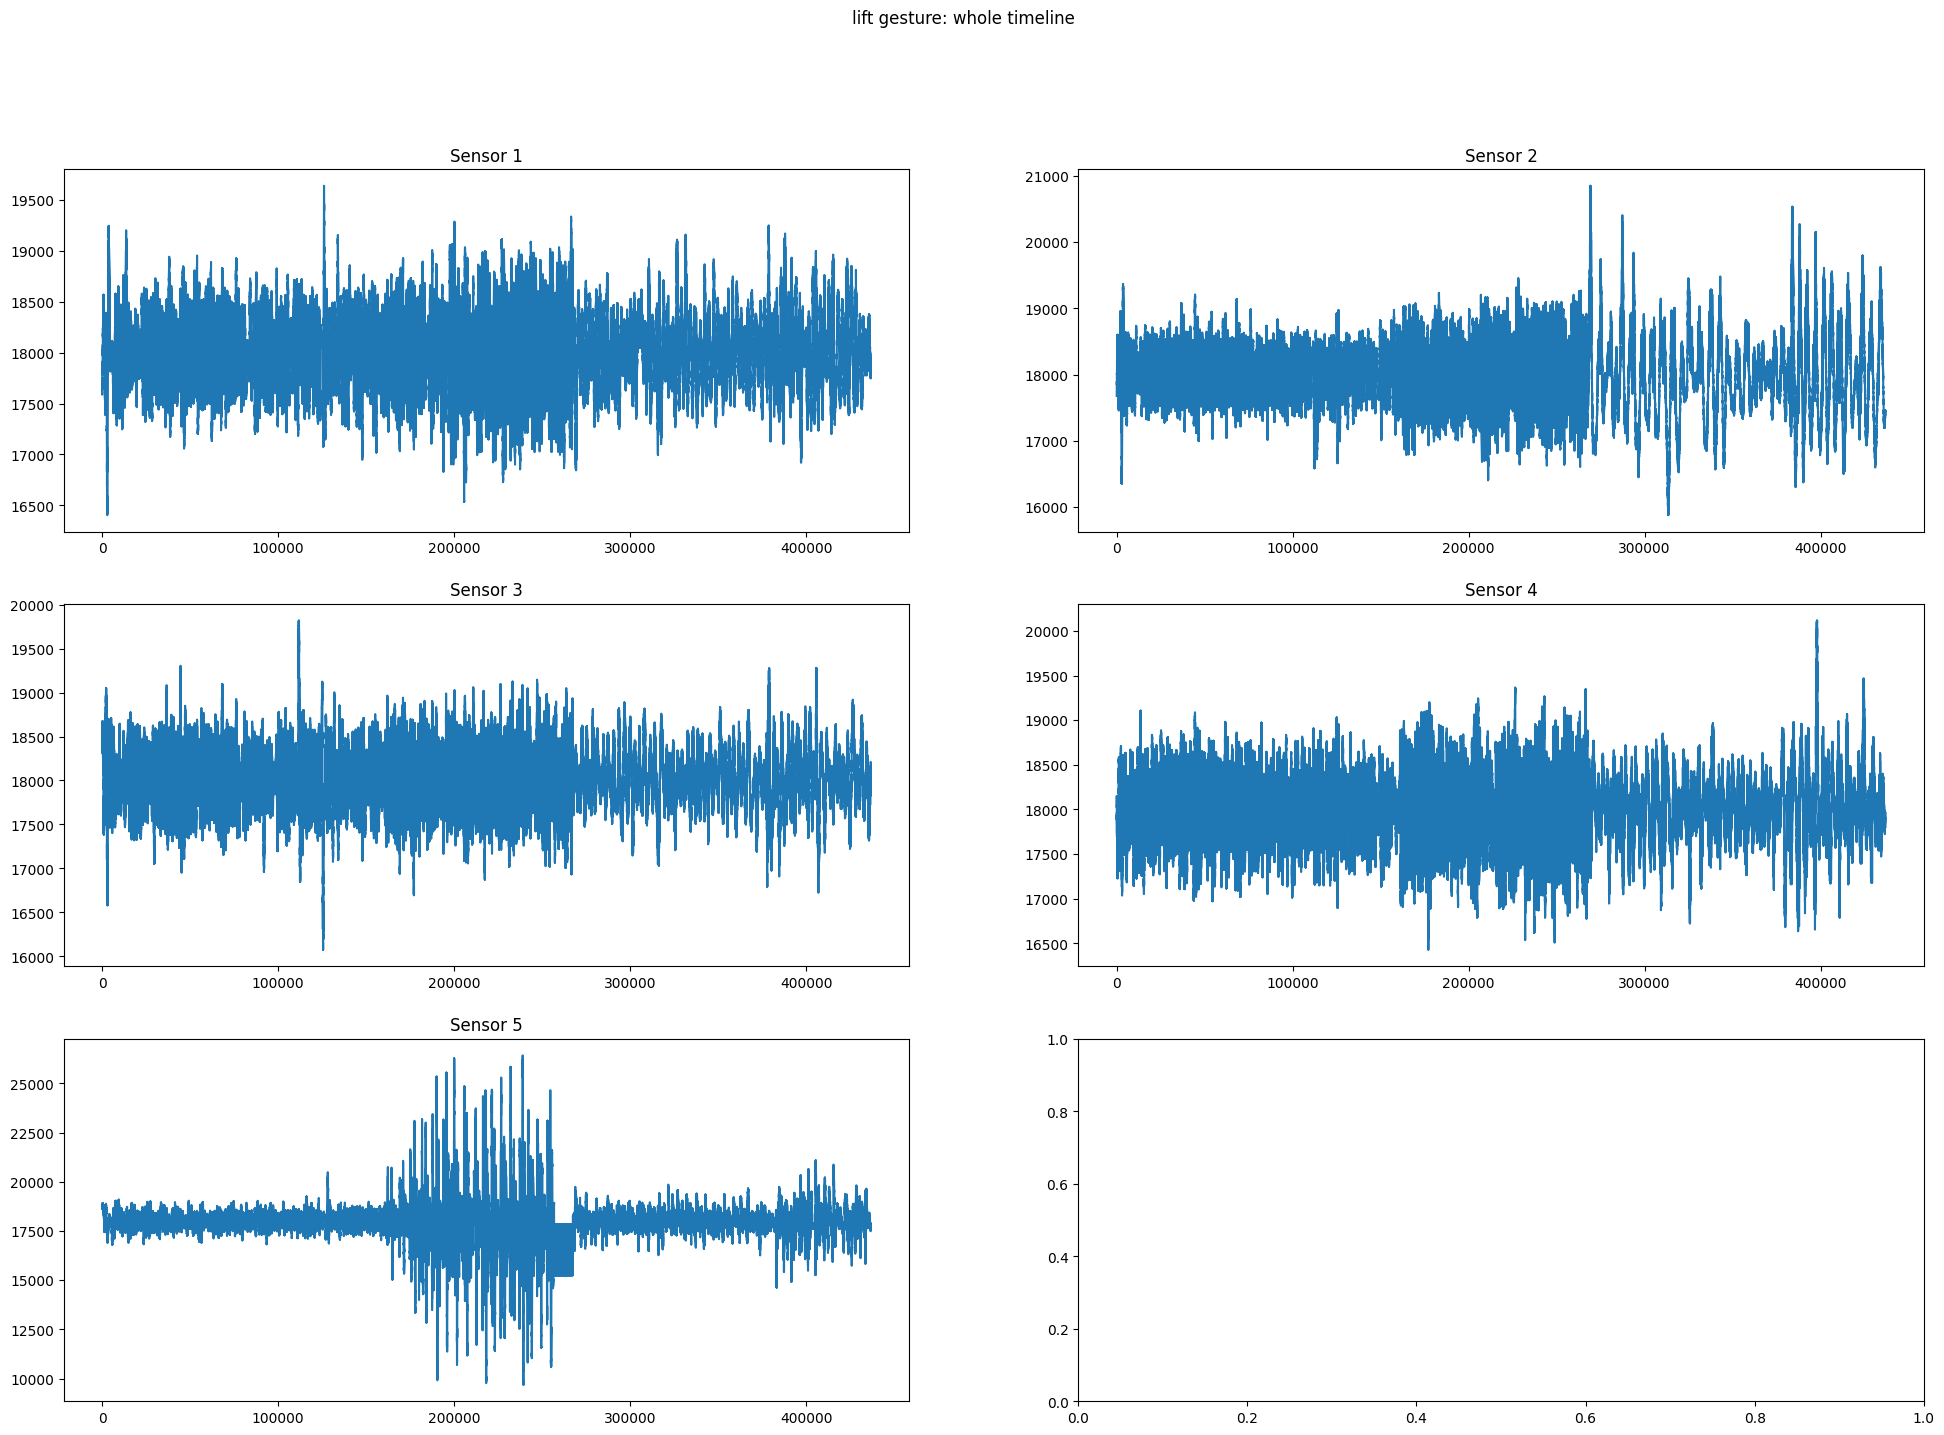

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


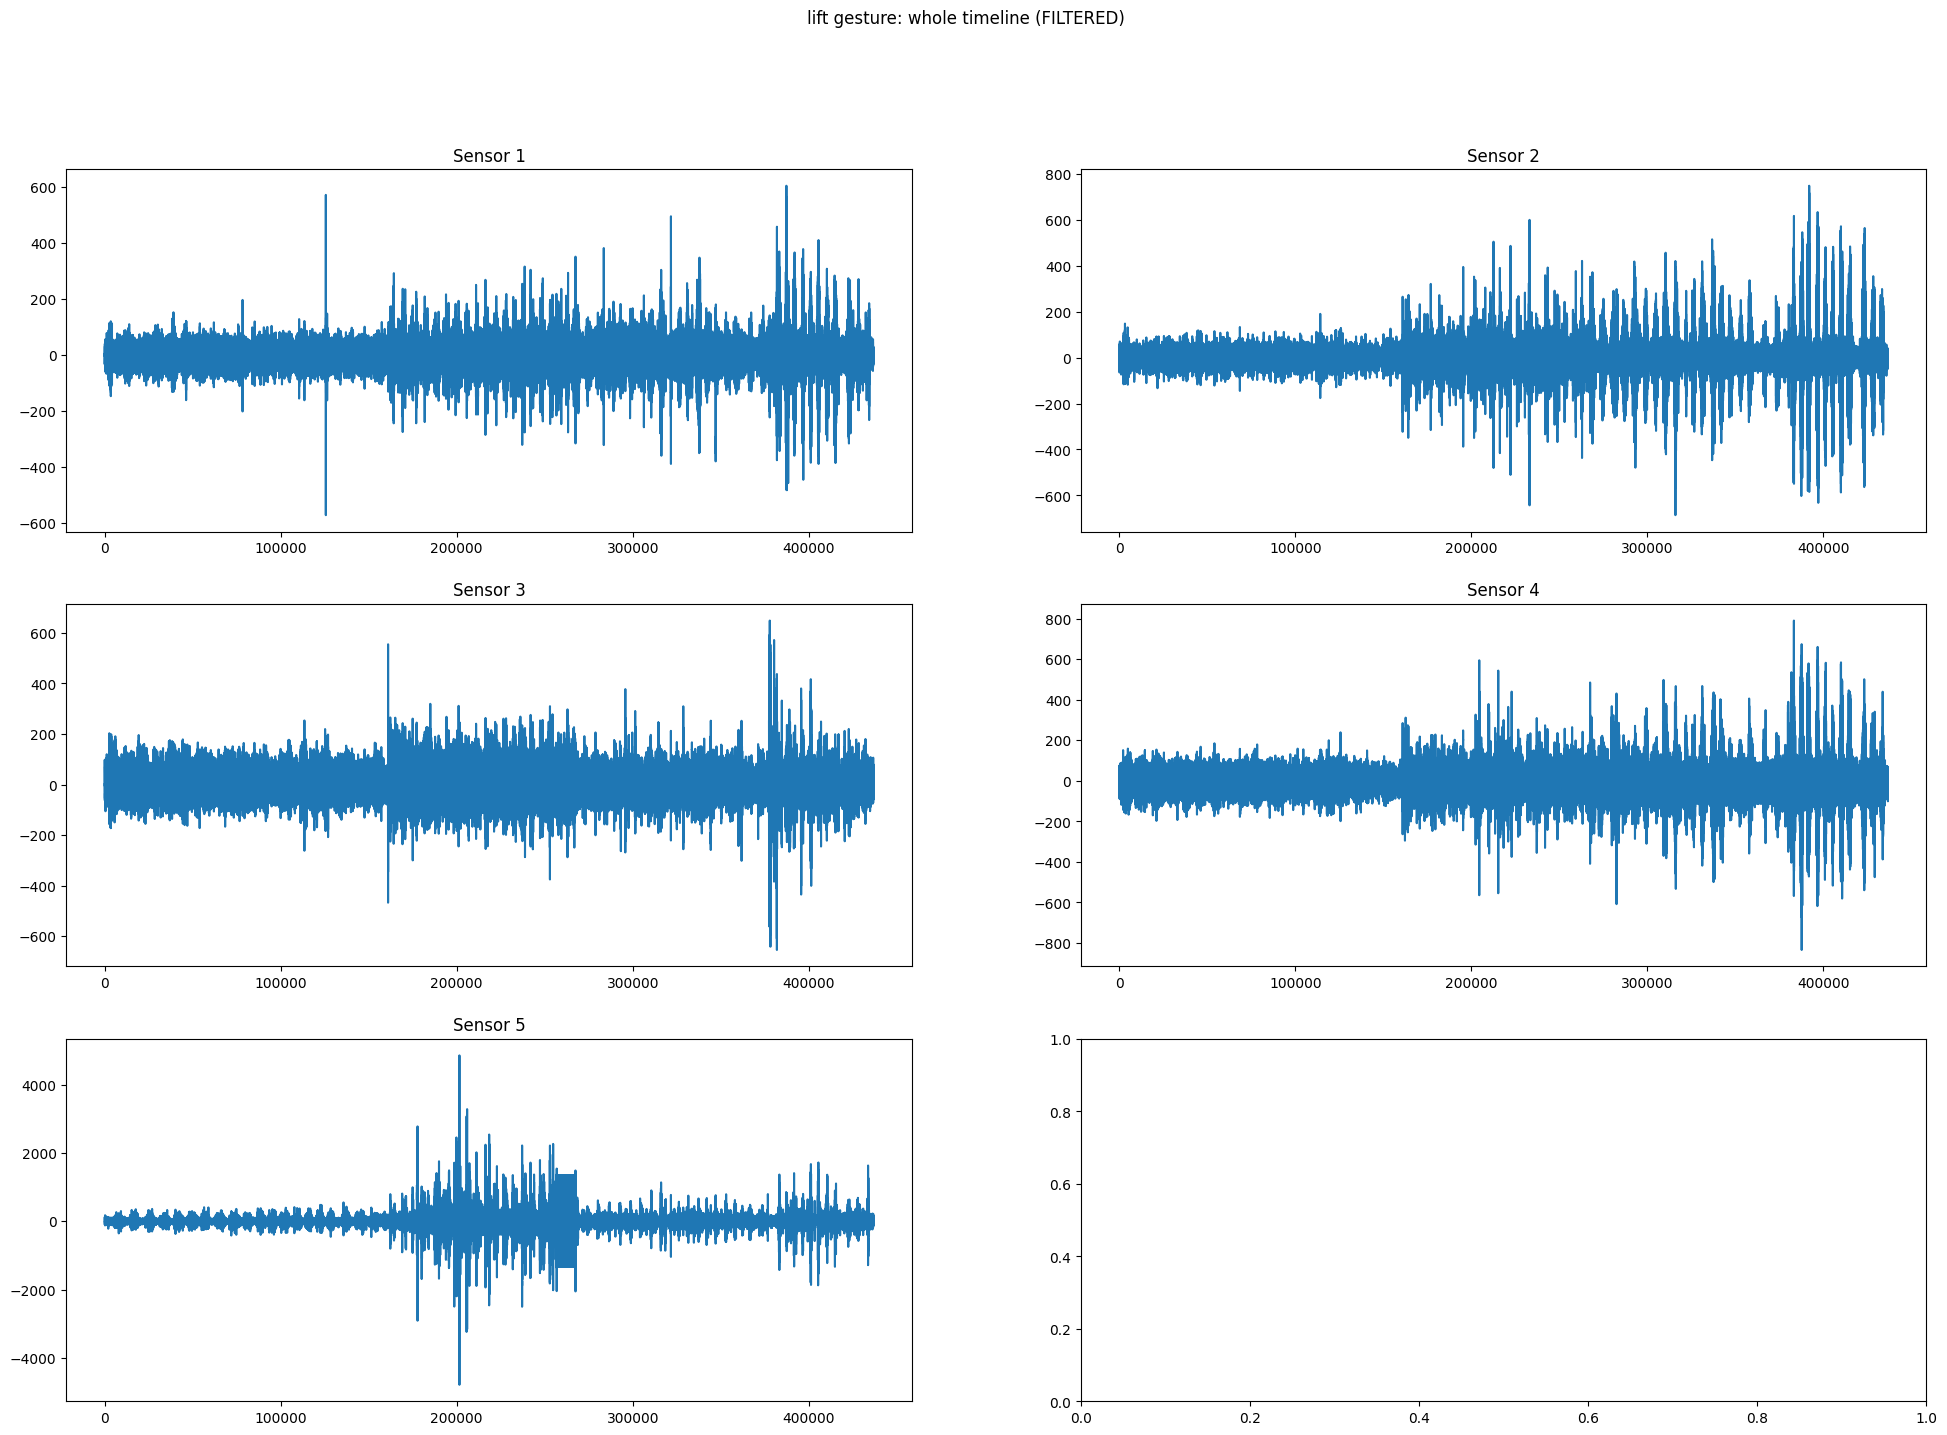

In [ ]:
preprocessor = preprocessing.EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, None, filter_type='band', library='libemg', num_sensors=NUM_SENSORS)

if PLOT_ALL_TIMELINE:
    for i in range(NUM_CLASSES):
        plot_all_time_signals(concat_dfs[i], title=f'{GESTURES[i]} gesture: whole timeline')
        plot_all_time_signals(concat_dfs[i], title=f'{GESTURES[i]} gesture: whole timeline (FILTERED)', preprocessor=preprocessor, filter=True)

## Class distribution

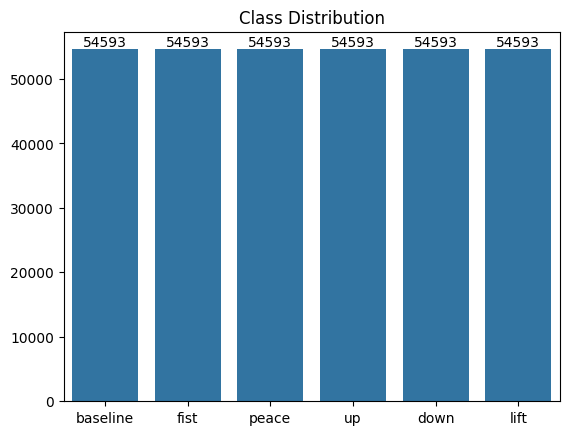

In [20]:
ax = sns.barplot(x=GESTURES, y=[len(df) for df in concat_dfs])
ax.bar_label(ax.containers[0])

plt.title('Class Distribution')
plt.show()

## Sensor correlation analysis

C:\Users\Gilbert\AppData\Local\Temp\ipykernel_2144\2709244429.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()


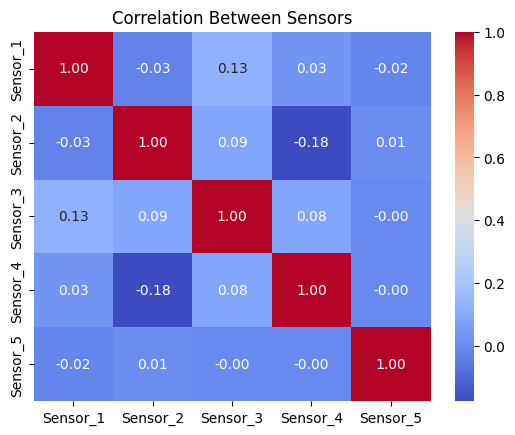

In [21]:
sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()

sensor_means.columns = [f"Sensor_{i+1}" for i in range(NUM_SENSORS)]

correlation = sensor_means.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensors")
plt.show()

## Dimensionality Reduction

C:\Users\Gilbert\AppData\Roaming\Python\Python311\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


(327558, 40)


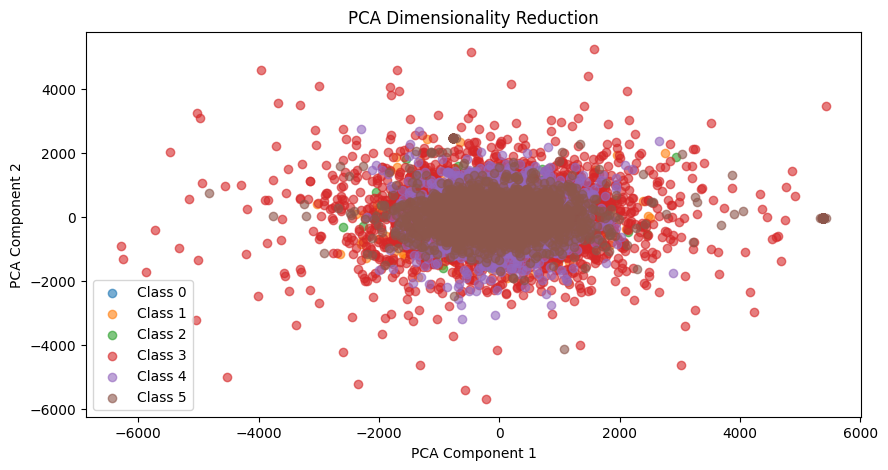

In [22]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)
# shape = sensor_data.shape
sensor_data_array = concat_dfs
sensor_preproc = [[] for _ in range(NUM_CLASSES)]
for i in range(NUM_CLASSES):
    shape_per_sensor = sensor_data_array[i].shape
    signals = np.array_split(sensor_data_array[i], NUM_SENSORS, axis=1)
    for sensor in range(0, NUM_SENSORS):
        sigs = signals[sensor]
        sig_shape = sigs.shape
        sigs = np.array(sigs.values).flatten()
        sigs = preprocessor.preprocess(sigs, sensor)
        sigs = sigs.reshape(sig_shape)
        signals[sensor] = sigs

    sensor_preproc[i] = np.asarray(signals).reshape(shape_per_sensor)
    
sensor_preproc = np.concatenate(sensor_preproc)
print(sensor_preproc.shape)
pca_result = pca.fit_transform(sensor_preproc)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [23]:
if USE_FFT:
    pca = PCA(n_components=2)
    # fft_sensor_preproc = np.concatenate(concat_fft_dfs)
    # pca_result = pca.fit_transform(fft_sensor_preproc)

    sensor_data_array = concat_fft_dfs
    sensor_preproc = [[] for _ in range(NUM_CLASSES)]
    for i in range(NUM_CLASSES):
        shape_per_sensor = sensor_data_array[i].shape
        signals = np.array_split(sensor_data_array[i].values, NUM_SENSORS, axis=1)
        sensor_preproc[i] = np.asarray(signals).reshape(shape_per_sensor)
        
    sensor_preproc = np.concatenate(sensor_preproc)
    pca_result = pca.fit_transform(sensor_preproc)

    # Plot PCA results
    plt.figure(figsize=(10, 5))
    for class_id in np.unique(labels):
        plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
    plt.title("PCA Dimensionality Reduction")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.show()

IndexError: boolean index did not match indexed array along dimension 0; dimension is 327557 but corresponding boolean dimension is 327558

<Figure size 1000x500 with 0 Axes>

## Train networks

In [ ]:
preprocessor = preprocessing.EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, None, filter_type='band', library='libemg')

In [25]:
# The set of windows extracted from the data as a NxCxL where N is the number of windows, C is the number of channels and L is the length of each window.
def preprocess_by_window(preprocessor, windows):
    for window in windows:
        for sensor in range(NUM_SENSORS):
            window[sensor, :] = preprocessor.preprocess(window[sensor, :], sensor)

In [26]:
from libemg.utils import get_windows
from libemg.feature_extractor import FeatureExtractor

def preprocess_per_sensor_avg(df, preprocessor, class_name, num_sensors=4, window_size=200, window_increment=100, num_readings=NUM_READINGS):
    for sensor in range(num_sensors):
        df[f'avg_{sensor}'] = df.iloc[:, sensor*num_readings:sensor*num_readings+num_readings].mean(axis=1)
    raw_signal = df.iloc[:, -NUM_SENSORS:].values
    raw_signal = get_windows(raw_signal, window_size=window_size, window_increment=window_increment)
    preprocess_by_window(preprocessor, raw_signal) 
    features_preshaped = raw_signal
    raw_signal = raw_signal.reshape(raw_signal.shape[0], -1)
    raw_signal = np.hstack((raw_signal, np.full((raw_signal.shape[0], 1), class_name)))
    return raw_signal, features_preshaped

class FFT_wrapper():
    def __init__(self, array):
        self.array = array
    def get_data(self):
        return self.array

def preprocess_per_sensor_fft(df, class_name, num_sensors=4, window_size=200, window_increment=100, num_readings=NUM_READINGS):
    raw_signal = df.values
    new_shape = (raw_signal.shape[0], num_sensors)
    raw_signal_wrapped = np.empty(shape=new_shape, dtype=object)
    for i in range(len(raw_signal)):
        sensor_data = np.array_split(raw_signal[i], num_sensors, axis=0)
        for sensor in range(num_sensors):
            raw_signal_wrapped[i, sensor] = FFT_wrapper(sensor_data[sensor])
    # print(raw_signal_wrapped[5, 0].get_data()) # 5th fft reading of 1st sensor
    raw_signal = get_windows(raw_signal_wrapped, window_size=window_size, window_increment=window_increment)
    # print(raw_signal[0, 0, 5].get_data()) # 5th fft reading of 1st sensor
    features_preshaped = raw_signal
    raw_signal = raw_signal.reshape(raw_signal.shape[0], -1)
    raw_signal = np.hstack((raw_signal, np.full((raw_signal.shape[0], 1), class_name)))
    return raw_signal, features_preshaped

def get_fft_features_per_sensor(windows, num_sensors=NUM_SENSORS):
    # obtain minimum and maximum for each bin
    features_shape = (windows.shape[0], num_sensors, 2*(NUM_FFT_READINGS-1))
    features = np.zeros(shape=features_shape, dtype=float)
    for i in range(windows.shape[0]):
        for sensor in range(num_sensors):
            min = np.array([[np.min([windows[i, sensor, w].get_data()[k] for w in range(windows.shape[2])])] for k in range(NUM_FFT_READINGS-1)])
            max = np.array([[np.max([windows[i, sensor, w].get_data()[k] for w in range(windows.shape[2])])] for k in range(NUM_FFT_READINGS-1)])
            # min = np.min([windows[i, sensor, w].get_data()[k] for w in range(windows.shape[2]) for k in range(NUM_FFT_READINGS-1)])
            features[i, sensor] = np.array([min, max]).reshape(-1)
    return features.reshape(features.shape[0], -1)

def preprocess_per_sensor(df, preprocessor, class_name, num_sensors=4, window_size=200, window_increment=100, num_readings=NUM_READINGS):
    raw_signal = df.values
    raw_signal = np.hstack([raw_signal[:, i::num_readings] for i in range(num_readings)])
    raw_signal = raw_signal.reshape(-1, num_sensors)
    raw_signal = get_windows(raw_signal, window_size=window_size, window_increment=window_increment)
    preprocess_by_window(preprocessor, raw_signal)
    features_preshaped = raw_signal
    raw_signal = raw_signal.reshape(raw_signal.shape[0], -1)
    raw_signal = np.hstack((raw_signal, np.full((raw_signal.shape[0], 1), class_name)))
    return raw_signal, features_preshaped

def get_features_per_sensor(windows, feature_groups=('HTD',)):
    fe = FeatureExtractor()
    
    features_list = []
    
    for feature_group in feature_groups:
        if feature_group not in fe.get_feature_groups().keys():
            raise ValueError(f"Invalid feature group: {feature_group}")

        features = fe.extract_feature_group(feature_group, windows, array=True)
        features_list.append(features)
    return np.concatenate(features_list, axis=1)

def check_invalid_features(features, classname, silent=True):
    fe = FeatureExtractor()

    invalid_features = fe.check_features(features, silent=silent)
    print(f'Invalid features for class {classname}: ', invalid_features)

In [27]:
def get_data_for_window_size(window_size, window_increment):
    windows = [[] for _ in range(NUM_CLASSES)]
    data_arrays = [[] for _ in range(NUM_CLASSES)]
    fft_data_arrays = [[] for _ in range(NUM_CLASSES)]
    fft_windows = [[] for _ in range(NUM_CLASSES)]
    for i, df in enumerate(concat_dfs):
        data_arrays[i], windows[i] = preprocess_per_sensor_avg(df, preprocessor, i, num_sensors=NUM_SENSORS, window_size=window_size, window_increment=window_increment)

    features = [[] for _ in range(NUM_CLASSES)]
    for i in range(NUM_CLASSES):
        features[i] = np.hstack((get_features_per_sensor(windows[i], feature_groups=('HJORTH', 'HTD')), np.full((windows[i].shape[0], 1), i)))

    if USE_FFT:
        for i, df in enumerate(concat_fft_dfs):
            fft_data_arrays[i], fft_windows[i] = preprocess_per_sensor_fft(df, i, num_sensors=NUM_SENSORS, window_size=window_size, window_increment=window_increment, num_readings=NUM_FFT_READINGS)
        
        fft_features = [[] for _ in range(NUM_CLASSES)]
        for i in range(NUM_CLASSES):
            fft_features[i] = np.hstack((get_fft_features_per_sensor(fft_windows[i]), np.full((fft_windows[i].shape[0], 1), i)))
    
    return data_arrays, fft_data_arrays, features, fft_features


In [28]:
WINDOW_SIZES = (50, 100, 150)
#WINDOW_SIZES = (28, 40, 50, 100, 150, 200)
data_arrays, fft_data_arrays, features, fft_features = [], [], [], []

for window_size in WINDOW_SIZES:
    data_array, fft_data_array, feature, fft_feature = get_data_for_window_size(window_size, window_size // 5)
    data_arrays.append(data_array)
    fft_data_arrays.append(fft_data_array)
    features.append(feature)
    fft_features.append(fft_feature)


In [29]:
def get_min_shape(data_arrays):
    min_shape = min([np.array(data_array).shape[1] for data_array in data_arrays])
    return min_shape

def get_random_array_chunk_starts(data_arrays, chunk_len):
    starts = []
    for arr in data_arrays:
        if arr.shape[1] == chunk_len:
            starts.append(0)
        else:
            starts.append(np.random.randint(0, arr.shape[1] - chunk_len))
    return starts

def get_random_array_chunk(data_arrays, chunk_len):
    starts = get_random_array_chunk_starts(data_arrays, chunk_len)
    data_arrays = [data_array[start:start+chunk_len] for (start, data_array) in zip(starts, data_arrays)]
    return data_arrays

In [30]:
min_len = get_min_shape(features)

In [31]:
X = np.vstack([arr[:, :-1] for arr in data_arrays[-1]])
y = np.hstack([arr[:, -1] for arr in data_arrays[-1]])

X_feat = np.vstack([arr[:, :-1] for arr in np.concatenate(features, axis=1)])
y_feat = np.hstack([arr[:, -1] for arr in np.concatenate(features, axis=1)])

if USE_FFT:
    X_fft = np.vstack([arr[:, :-1] for arr in fft_data_arrays[-1]])
    X_fft_unwrapped = np.zeros((X_fft.shape[0], X_fft.shape[1], NUM_FFT_READINGS), dtype=float)
    for i in range(X_fft.shape[0]):
        for j in range(X_fft.shape[1]):
            for k in range(NUM_FFT_READINGS-1):
                X_fft_unwrapped[i, j, k] = X_fft[i, j].get_data()[k]
    X_fft = X_fft_unwrapped.reshape(X_fft_unwrapped.shape[0], -1)
    
    X_fft_feat = np.vstack([arr[:, :-1] for arr in np.concatenate(fft_features, axis=1)])
    X_feat = np.hstack((X_feat, X_fft_feat))

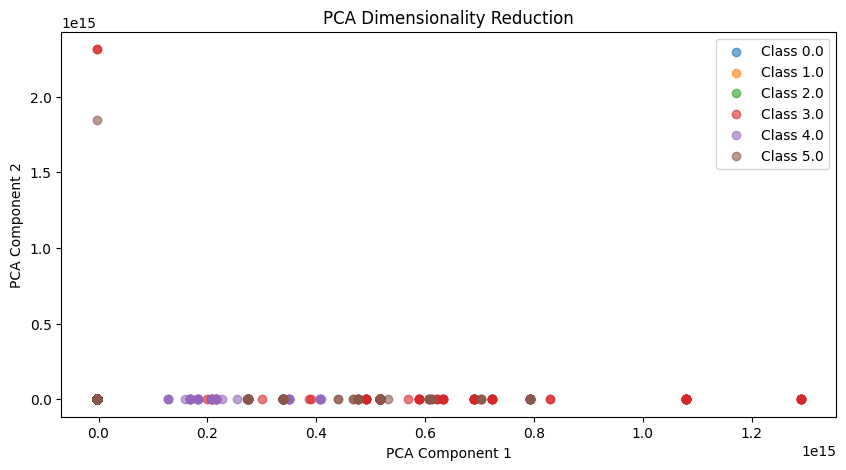

In [32]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_feat)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(y_feat):
    plt.scatter(pca_result[y_feat == class_id, 0], pca_result[y_feat == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [33]:
print(X.shape, y.shape, X_feat.shape, y_feat.shape)

(10890, 750) (10890,) (59970, 65) (59970,)


In [34]:
print(X.max(), X.min(), X_feat.max(), X_feat.min())

5536.940676548889 -4600.638865380123 2312802457161825.0 0.0


Use separate scalars for raw data and features and save both:

In [35]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

with open("scaler_raw_data.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [36]:
scaler = StandardScaler()

X_feat = scaler.fit_transform(X_feat)

with open("scaler_features.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [37]:
print(X.max(), X.min(), X_feat.max(), X_feat.min())

48.45611544286925 -39.09848085435367 150.80561851871266 -5.012470205610489


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(X_feat, y_feat, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

In [39]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape
X_train_feat.shape, X_test_feat.shape, y_train_feat.shape, y_test_feat.shape

((47976, 65), (11994, 65), (47976,), (11994,))

## Classical models

In [40]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', max_depth=100, random_state=RANDOM_STATE)
# clf.fit(X_train, y_train)
clf.fit(X_train_feat, y_train_feat)

RandomForestClassifier(max_depth=100, random_state=42)

In [41]:
depths = [estimator.get_depth() for estimator in clf.estimators_]
min(depths), max(depths)

(31, 48)

In [42]:
with open("random_forest_model.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [43]:
y_pred = clf.predict(X_train_feat)

print('Classification Report: \n', classification_report(y_train_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7992
         1.0       1.00      1.00      1.00      8041
         2.0       1.00      1.00      1.00      8012
         3.0       1.00      1.00      1.00      7963
         4.0       1.00      1.00      1.00      7991
         5.0       1.00      1.00      1.00      7977

    accuracy                           1.00     47976
   macro avg       1.00      1.00      1.00     47976
weighted avg       1.00      1.00      1.00     47976

Confusion Matrix: 
 [[7992    0    0    0    0    0]
 [   0 8041    0    0    0    0]
 [   0    0 8012    0    0    0]
 [   0    0    0 7963    0    0]
 [   0    0    0    0 7991    0]
 [   0    0    0    0    0 7977]]


In [44]:
y_pred = clf.predict(X_test_feat)

In [45]:
print('Classification Report: \n', classification_report(y_test_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       0.88      0.97      0.92      2003
         1.0       0.93      0.94      0.93      1954
         2.0       0.92      0.93      0.93      1983
         3.0       0.98      0.87      0.92      2032
         4.0       0.95      0.94      0.95      2004
         5.0       0.96      0.95      0.96      2018

    accuracy                           0.93     11994
   macro avg       0.94      0.93      0.93     11994
weighted avg       0.94      0.93      0.93     11994

Confusion Matrix: 
 [[1947   10   10    2    8   26]
 [  35 1827   39   17   30    6]
 [  63   26 1853   12   21    8]
 [  67   57   70 1773   32   33]
 [  42   31   33    5 1893    0]
 [  71    8   12    6    3 1918]]


In [46]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(7)
clf.fit(X_train_feat, y_train_feat)

KNeighborsClassifier(n_neighbors=7)

In [47]:
y_pred = clf.predict(X_test_feat)
print('Classification Report: \n', classification_report(y_test_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       0.67      0.90      0.77      2003
         1.0       0.82      0.80      0.81      1954
         2.0       0.77      0.78      0.78      1983
         3.0       0.88      0.76      0.82      2032
         4.0       0.90      0.83      0.87      2004
         5.0       0.94      0.83      0.88      2018

    accuracy                           0.82     11994
   macro avg       0.83      0.82      0.82     11994
weighted avg       0.83      0.82      0.82     11994

Confusion Matrix: 
 [[1811   24   63   30   14   61]
 [ 157 1555  119   38   79    6]
 [ 212   78 1546   83   44   20]
 [ 159  106  164 1541   41   21]
 [ 123  104   66   33 1672    6]
 [ 249   18   42   19    6 1684]]


In [48]:
with open("knn.pkl", "wb") as f:
    dump(clf, f, protocol=5)

## Test different classical ML models

Testing different classification models with common parameters based on https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html.

In [49]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=RANDOM_STATE),
    SVC(gamma=2, C=1, random_state=RANDOM_STATE),
    DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=RANDOM_STATE
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=RANDOM_STATE),
    AdaBoostClassifier(algorithm="SAMME", random_state=RANDOM_STATE),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

for name, clf in zip(names, classifiers):
    clf.fit(X_train_feat, y_train_feat)
    y_pred = clf.predict(X_test_feat)
    
    print(f'{name} results:')
    print('Classification Report: \n', classification_report(y_test_feat, y_pred))
    print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))
    print()

Nearest Neighbors results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.69      0.90      0.78      2003
         1.0       0.85      0.85      0.85      1954
         2.0       0.83      0.79      0.81      1983
         3.0       0.91      0.81      0.86      2032
         4.0       0.93      0.87      0.90      2004
         5.0       0.95      0.86      0.90      2018

    accuracy                           0.85     11994
   macro avg       0.86      0.85      0.85     11994
weighted avg       0.86      0.85      0.85     11994

Confusion Matrix: 
 [[1812   29   60   32   13   57]
 [ 132 1668   67   27   56    4]
 [ 205   85 1568   71   39   15]
 [ 144   94  106 1649   23   16]
 [ 123   70   48   24 1738    1]
 [ 205   18   37   13    2 1743]]

Linear SVM results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.61      0.86      0.72      2003
         1.0       0.56      0.

c:\Users\Gilbert\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\discriminant_analysis.py:949: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


The models used in by libemg are also based on Scikit-Learn and mostly use the [standard parameters](https://github.com/LibEMG/libemg/blob/main/libemg/emg_predictor.py#L225):

```python
model_config = {
    'LDA': (LinearDiscriminantAnalysis, {}),
    'KNN': (KNeighborsClassifier, {"n_neighbors": 5}),
    'SVM': (SVC, {"kernel": "linear", "probability": True, "random_state": 0}),
    'QDA': (QuadraticDiscriminantAnalysis, {}),
    'RF': (RandomForestClassifier, {"random_state": 0}),
    'NB': (GaussianNB, {}),
    'GB': (GradientBoostingClassifier, {"random_state": 0}),
    'MLP': (MLPClassifier, {"random_state": 0, "hidden_layer_sizes": 126})
}
```

## Deep Learning

### Feed Forward Neural Network

The FFNN will be trained on the extracted features from the EMG signals.

In [50]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, layer_sizes, dropout_rates):
        super(NeuralNet, self).__init__()
        
        assert len(layer_sizes) >= 2, "layer_sizes must include at least input and output sizes"
        assert len(dropout_rates) == len(layer_sizes) - 2, "dropout_rates must match the number of hidden layers"
        
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(dropout_rates):  # Apply dropout only to hidden layers
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout_rates[i]))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)


In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [52]:
def train_model(model, train_dataloader, test_loader, n_epochs, learning_rate, verbose=True):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1)
    
    for epoch in range(n_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        model.train()
        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute running loss and accuracy
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        test_accuracy, test_loss = calculate_accuracy(model, test_loader)

        scheduler.step(running_loss / total)
        
        if verbose:
            epoch_loss = running_loss / len(train_dataloader.dataset)
            epoch_accuracy = correct / total * 100

            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

    return model

def calculate_accuracy(model, test_dataloader, loss_fn=nn.CrossEntropyLoss()):
    running_loss = 0.0
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total * 100, running_loss / total

In [53]:
input_size = X_train_feat.shape[1]
output_size = int(y_train_feat.max() + 1)
batch_size = 256
epochs = 200
learning_rate = 0.001

X_train_tensor = torch.tensor(X_train_feat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_feat, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_feat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_feat, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [54]:
models_architectures = [
    #{'layer_sizes': [input_size, 1024, 1024, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 128, 32, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 32, 32, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 32, output_size], 'dropout_rates': [0.2]},
    {'layer_sizes': [input_size, 8, output_size], 'dropout_rates': [0.2]},
]

In [55]:
models = []

for i, architecture in enumerate(models_architectures):
    model = NeuralNet(architecture['layer_sizes'], architecture['dropout_rates']).to(device)
    print(f"Training model {i+1} with {sum(p.numel() for p in model.parameters())} weights")
    model = train_model(model, train_loader, test_loader, epochs, learning_rate, verbose=False)
    print(f"Model {i+1} train accuracy: {calculate_accuracy(model, train_loader)[0]:.2f}% test accuracy: {calculate_accuracy(model, test_loader)[0]:.2f}%\n")
    models.append(model)

Training model 1 with 12774 weights
Model 1 train accuracy: 93.17% test accuracy: 88.67%

Training model 2 with 3366 weights
Model 2 train accuracy: 85.04% test accuracy: 83.32%

Training model 3 with 2310 weights
Model 3 train accuracy: 82.61% test accuracy: 81.02%

Training model 4 with 582 weights
Model 4 train accuracy: 67.63% test accuracy: 67.59%



In [56]:
model_scripted = torch.jit.script(models[0])
model_scripted.save('ffnn_model.pt')

In [57]:
model_scripted = torch.jit.script(models[1])
model_scripted.save('ffnn_model_2.pt')

In [58]:
model_scripted = torch.jit.script(models[3])
model_scripted.save('ffnn_model_3.pt')

In [59]:
X_test_tensor[7], y_test_tensor[7]

(tensor([-0.4724, -0.2539, -0.3187, -0.4634, -0.1144,  0.4870, -0.9972,  0.6206,
          0.1702, -0.8881, -0.0197, -0.0126, -0.0120, -0.0070, -0.0740, -1.0550,
         -0.2984, -0.5336, -0.7013, -0.2120, -0.7466, -0.9050, -0.5901, -0.6308,
         -0.7648, -0.8812, -0.9373, -0.5892, -0.6508, -0.6267, -1.1402, -0.9057,
         -0.7316, -0.9072, -0.4781, -0.4199,  0.1489, -0.5424, -0.8153, -0.7510,
         -0.6382, -0.1028, -0.8619, -0.6377, -0.8281, -0.7041, -0.8599, -0.2662,
         -0.1471,  0.9538, -0.6591, -0.3932, -0.4170, -0.0889, -0.3591, -0.2647,
         -0.6387, -0.6496, -0.6856, -0.0324, -0.0223, -0.0140, -0.6133, -0.2047,
         -0.3411]),
 tensor(0))

In [60]:
logits = models[0](X_test_tensor[7].unsqueeze(0).to(device))
shifted_logits = logits - logits.min(dim=1, keepdim=True).values
normalized_logits = shifted_logits / (shifted_logits.sum(dim=1, keepdim=True) + 1e-8)
print(logits)
print(normalized_logits)

tensor([[ 1.7062, -8.7635,  1.2695,  0.4668, -9.9362,  2.2287]],
       grad_fn=<AddmmBackward0>)
tensor([[0.2499, 0.0252, 0.2405, 0.2233, 0.0000, 0.2611]],
       grad_fn=<DivBackward0>)


In [61]:
gc.collect()

0

### LSTM (Long Short-Term Memory)

Unlike the FFNN that was trained on the extracted features, the LSTM will be trained on the raw EMG signals (time series).

In [62]:
class PureLSTM(nn.Module):

    def __init__(self, n_features, n_hidden, n_sequence, n_layers, n_classes, bidirectional=False):
        super(PureLSTM, self).__init__()

        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_sequence = n_sequence
        self.n_layers = n_layers
        self.n_classes = n_classes
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.linear_1 = nn.Linear(in_features=n_hidden * (2 if bidirectional else 1), out_features=128)
        self.dropout_1 = nn.Dropout(p=0.2)

        self.linear_2 = nn.Linear(in_features=128, out_features=n_classes)

    def forward(self, x):
        device = x.device
        hidden = (
            torch.zeros(self.n_layers * (2 if self.bidirectional else 1), x.shape[0], self.n_hidden).to(device),
            torch.zeros(self.n_layers * (2 if self.bidirectional else 1), x.shape[0], self.n_hidden).to(device),
        )

        out, (hs, cs) = self.lstm(x.view(len(x), self.n_sequence, -1), hidden)
        out = out[:, -1, :]

        out = self.linear_1(out)
        out = self.dropout_1(out)
        out = self.linear_2(out)

        return out

In [63]:
n_features = NUM_SENSORS
n_sequence = int(X_train.shape[1] / n_features)
epochs = 200
learning_rate = 0.005

print("Train Data Shape ",X_train.shape, y_train.shape)
print("Test Data Shape ",X_test.shape, y_test.shape)

X_train_mod = X_train.reshape(X_train.shape[0], n_features, n_sequence)
X_train_mod = np.swapaxes(X_train_mod, 2, 1)

X_test_mod = X_test.reshape(X_test.shape[0], n_features, n_sequence)
X_test_mod = np.swapaxes(X_test_mod, 2, 1)

print("Train Data Shape ",X_train_mod.shape)
print("Test Data Shape ",X_test_mod.shape)

X_train_tensor = torch.tensor(X_train_mod, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_mod, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Train Data Shape  (8712, 750) (8712,)
Test Data Shape  (2178, 750) (2178,)
Train Data Shape  (8712, 150, 5)
Test Data Shape  (2178, 150, 5)


In [64]:
n_hidden = 16
n_layers = 2
model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size, bidirectional=False).to(device)

In [65]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

PureLSTM(
  (lstm): LSTM(5, 16, num_layers=2, batch_first=True)
  (linear_1): Linear(in_features=16, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=6, bias=True)
)
Number of weights: 6598


In [66]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 1.7676, Accuracy: 21.14%, Test Accuracy: 28.01%
Epoch 2/200, Loss: 1.6582, Accuracy: 30.15%, Test Accuracy: 22.64%
Epoch 3/200, Loss: 1.6690, Accuracy: 26.30%, Test Accuracy: 28.15%
Epoch 4/200, Loss: 1.5411, Accuracy: 33.53%, Test Accuracy: 36.59%
Epoch 5/200, Loss: 1.4790, Accuracy: 36.50%, Test Accuracy: 34.53%
Epoch 6/200, Loss: 1.4707, Accuracy: 36.88%, Test Accuracy: 37.10%
Epoch 7/200, Loss: 1.4526, Accuracy: 38.93%, Test Accuracy: 37.70%
Epoch 8/200, Loss: 1.4439, Accuracy: 38.13%, Test Accuracy: 39.67%
Epoch 9/200, Loss: 1.3998, Accuracy: 41.92%, Test Accuracy: 42.01%
Epoch 10/200, Loss: 1.3844, Accuracy: 42.98%, Test Accuracy: 42.75%
Epoch 11/200, Loss: 1.3823, Accuracy: 43.29%, Test Accuracy: 36.13%
Epoch 12/200, Loss: 1.4312, Accuracy: 40.17%, Test Accuracy: 43.39%
Epoch 13/200, Loss: 1.5496, Accuracy: 35.15%, Test Accuracy: 29.80%
Epoch 14/200, Loss: 1.5614, Accuracy: 33.41%, Test Accuracy: 39.76%
Epoch 15/200, Loss: 1.4363, Accuracy: 41.55%, Test Accura

KeyboardInterrupt: 

In [115]:
model_scripted = torch.jit.script(model)
model_scripted.save('lstm_model.pt')

Try LSTM with bidirectional layers.

In [135]:
n_hidden = 16
n_layers = 2
model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size, bidirectional=True).to(device)

In [136]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

PureLSTM(
  (lstm): LSTM(5, 16, num_layers=2, batch_first=True, bidirectional=True)
  (linear_1): Linear(in_features=32, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=9, bias=True)
)
Number of weights: 14729


In [137]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 2.1114, Accuracy: 18.38%, Test Accuracy: 25.75%
Epoch 2/200, Loss: 2.1238, Accuracy: 22.58%, Test Accuracy: 26.02%
Epoch 3/200, Loss: 1.8282, Accuracy: 29.87%, Test Accuracy: 35.52%
Epoch 4/200, Loss: 1.6009, Accuracy: 38.51%, Test Accuracy: 34.05%
Epoch 5/200, Loss: 1.5934, Accuracy: 37.63%, Test Accuracy: 38.06%
Epoch 6/200, Loss: 1.5170, Accuracy: 42.11%, Test Accuracy: 39.67%
Epoch 7/200, Loss: 1.7486, Accuracy: 35.30%, Test Accuracy: 44.68%
Epoch 8/200, Loss: 1.5576, Accuracy: 41.72%, Test Accuracy: 39.13%
Epoch 9/200, Loss: 1.5491, Accuracy: 41.62%, Test Accuracy: 43.95%
Epoch 10/200, Loss: 1.4629, Accuracy: 43.80%, Test Accuracy: 47.36%
Epoch 11/200, Loss: 1.4295, Accuracy: 45.90%, Test Accuracy: 49.03%
Epoch 12/200, Loss: 1.3470, Accuracy: 48.80%, Test Accuracy: 47.42%
Epoch 13/200, Loss: 1.3075, Accuracy: 50.12%, Test Accuracy: 53.98%
Epoch 14/200, Loss: 1.3972, Accuracy: 48.51%, Test Accuracy: 47.56%
Epoch 15/200, Loss: 1.3410, Accuracy: 50.90%, Test Accura

KeyboardInterrupt: 

In [119]:
model_scripted = torch.jit.script(model)
model_scripted.save('lstm_bidrection_model.pt')

In [120]:
def evaluateModel(outputs, y):
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y).sum().item() / y.size(0) * 100
    return test_accuracy, predicted

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_hat_test = model(X_test_tensor)
    acc, predicted = evaluateModel(y_hat_test, y_test_tensor)
    print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 84.42%


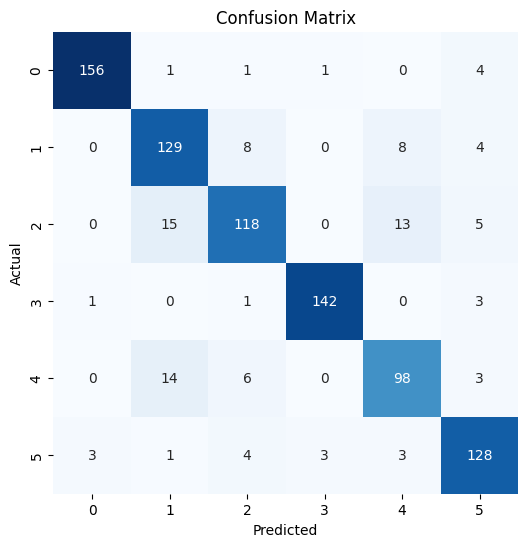

In [117]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Transformer

In [67]:
import torch
import torch.nn as nn

class TransformerTimeSeries(nn.Module):
    def __init__(self, n_features, n_sequence, n_hidden, n_heads, n_layers, n_classes, dropout=0.1):
        super(TransformerTimeSeries, self).__init__()
        
        self.n_features = n_features
        self.n_sequence = n_sequence
        
        # Input embedding layer
        self.input_embedding = nn.Linear(n_features, n_hidden)
        
        # Positional encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, n_sequence, n_hidden))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=n_hidden,
            nhead=n_heads,
            dim_feedforward=n_hidden * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Fully connected layers
        self.linear_1 = nn.Linear(n_hidden, 128)
        self.dropout_1 = nn.Dropout(p=dropout)
        self.linear_2 = nn.Linear(128, n_classes)

    def forward(self, x):
        # Apply input embedding
        x = self.input_embedding(x)  # Shape: (batch_size, n_sequence, n_hidden)
        
        # Add positional encoding
        x = x + self.positional_encoding
        
        # Pass through Transformer encoder
        x = self.transformer_encoder(x)  # Shape: (batch_size, n_sequence, n_hidden)
        
        # Extract the representation of the last time step
        x = x[:, -1, :]  # Shape: (batch_size, n_hidden)
        
        # Pass through fully connected layers
        x = self.linear_1(x)
        x = self.dropout_1(x)
        x = self.linear_2(x)
        
        return x


In [68]:
n_features = NUM_SENSORS
n_sequence = int(X_train_feat.shape[1] / n_features)
n_hidden = 16
n_layers = 2

print("Train Feat Data Shape ",X_train_feat.shape, y_train_feat.shape)
print("Test Feat Data Shape ",X_test_feat.shape, y_test_feat.shape)

X_train_mod = X_train_feat.reshape(X_train_feat.shape[0], n_features, n_sequence)
X_train_mod = np.swapaxes(X_train_mod, 2, 1)

X_test_mod = X_test_feat.reshape(X_test_feat.shape[0], n_features, n_sequence)
X_test_mod = np.swapaxes(X_test_mod, 2, 1)

print("Train Feat Modified Data Shape ",X_train_mod.shape)
print("Test Feat Modified Data Shape ",X_test_mod.shape)

X_train_tensor = torch.tensor(X_train_mod, dtype=torch.float32)
print(X_train_tensor[7])
y_train_tensor = torch.tensor(y_train_feat, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_mod, dtype=torch.float32)
print(X_test_tensor[7])
y_test_tensor = torch.tensor(y_test_feat, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Train Feat Data Shape  (47976, 65) (47976,)
Test Feat Data Shape  (11994, 65) (11994,)
Train Feat Modified Data Shape  (47976, 13, 5)
Test Feat Modified Data Shape  (11994, 13, 5)
tensor([[ 0.0082, -0.0070,  2.0919,  2.5634,  0.2313],
        [ 0.0279, -0.0740,  1.6143,  2.1234, -0.8819],
        [-0.1206,  0.2924,  1.9041,  0.2889, -0.5392],
        [-0.1697,  0.5170,  1.5652, -0.4050, -0.3794],
        [-0.1156,  0.0714,  2.3867, -1.0027,  0.0259],
        [ 0.5122,  0.0533,  2.7172,  0.1655,  0.0159],
        [ 1.0716, -0.2504,  1.2917,  1.2150,  0.4582],
        [-0.2073,  1.8036,  1.6501,  1.0415, -0.1750],
        [ 0.5154,  1.9837,  0.4062, -0.7084, -0.1508],
        [ 1.0100,  1.6452, -0.3205,  0.3350,  0.0447],
        [-0.0197,  1.6043, -0.9349,  0.5415, -0.0700],
        [-0.0126,  2.3233, -0.3738,  0.5622, -0.1618],
        [-0.0120,  1.7247,  1.3602,  0.4559,  0.0452]])
tensor([[-0.4724, -0.0070, -0.9373, -0.7510, -0.4170],
        [-0.2539, -0.0740, -0.5892, -0.6382, -0.0

In [69]:
n_heads = 4
dropout = 0.2

model = TransformerTimeSeries(n_features, n_sequence, n_hidden, n_heads, n_layers, output_size, dropout).to(device)

In [70]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

TransformerTimeSeries(
  (input_embedding): Linear(in_features=5, out_features=16, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (linear1): Linear(in_features=16, out_features=64, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=64, out_features=16, bias=True)
        (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (linear_1): Linear(in_features=16, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=6, bias=True)
)
Number of weights: 

In [71]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 1.1328, Accuracy: 55.27%, Test Accuracy: 65.98%
Epoch 2/200, Loss: 0.9339, Accuracy: 64.02%, Test Accuracy: 69.33%
Epoch 3/200, Loss: 0.8624, Accuracy: 66.82%, Test Accuracy: 72.30%
Epoch 4/200, Loss: 0.8250, Accuracy: 68.51%, Test Accuracy: 73.08%
Epoch 5/200, Loss: 0.8020, Accuracy: 69.45%, Test Accuracy: 73.62%
Epoch 6/200, Loss: 0.7861, Accuracy: 70.07%, Test Accuracy: 74.28%
Epoch 7/200, Loss: 0.7697, Accuracy: 70.61%, Test Accuracy: 74.99%
Epoch 8/200, Loss: 0.7557, Accuracy: 71.31%, Test Accuracy: 75.63%
Epoch 9/200, Loss: 0.7409, Accuracy: 71.76%, Test Accuracy: 75.22%
Epoch 10/200, Loss: 0.7281, Accuracy: 72.45%, Test Accuracy: 76.15%
Epoch 11/200, Loss: 0.7225, Accuracy: 72.51%, Test Accuracy: 75.95%
Epoch 12/200, Loss: 0.7121, Accuracy: 73.15%, Test Accuracy: 75.05%
Epoch 13/200, Loss: 0.7092, Accuracy: 73.03%, Test Accuracy: 77.28%
Epoch 14/200, Loss: 0.7106, Accuracy: 73.18%, Test Accuracy: 75.97%
Epoch 15/200, Loss: 0.6949, Accuracy: 73.62%, Test Accura

In [72]:
model_scripted = torch.jit.script(model)
model_scripted.save('transformer_model.pt')